# Pipeline MCTNet — California + Arkansas (Table 2)
## ÉTAPE 1 : Alignement CDL → ÉTAPE 2 : Cube spectral 10 bandes → ÉTAPE 3 : MCT-Net
## Deux études de zone séparées dans le même notebook

> **Structure attendue :**
> ```
> data/
>   raw/
>     californiaX.SAFE
>     arkansasX.SAFE
>   processed/
>     cdl_california_2021.tif
>     cdl_arkansas_2021.tif
> models/
> ```


## 📦 Imports

In [1]:
import os, glob, warnings
import numpy as np
import pandas as pd
import rasterio
import math
from rasterio.warp import reproject, Resampling as WarpResampling
from rasterio.enums import Resampling
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi']        = 130
plt.rcParams['font.family']       = 'DejaVu Sans'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid']         = True
plt.rcParams['grid.alpha']        = 0.4
plt.rcParams['grid.linestyle']    = '--'

print(f'PyTorch  : {torch.__version__}')
print(f'Rasterio : {rasterio.__version__}')
gpu = torch.cuda.get_device_name(0) if torch.cuda.is_available() else None
print(f'GPU dispo: {"ok " + gpu if gpu else "CPU uniquement"}')
print('Imports OK')
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))


PyTorch  : 2.5.1+cu121
Rasterio : 1.4.4
GPU dispo: ok NVIDIA GeForce RTX 4050 Laptop GPU
Imports OK
2.5.1+cu121
True
NVIDIA GeForce RTX 4050 Laptop GPU


## ⚙️ Configuration — Auto-discovery des nouvelles images

> **✅ Après avoir téléchargé de nouvelles images avec `download_sentinel2.py` :**
> Il suffit de **relancer cette cellule** — les nouveaux `.SAFE` sont détectés automatiquement dans `data/raw/` et ajoutés aux `DATES_MAP`.
> Aucune modification manuelle du code n'est nécessaire.

> **Structure des fichiers attendue :**
> ```
> data/raw/
>   S2A_MSIL2A_20210315T184921_..._T10SGH_....SAFE/   ← nouveau téléchargé
>   california1.SAFE/   ← existant
>   arkansas1.SAFE/     ← existant
>   ...
> ```

In [63]:
# ══════════════════════════════════════════════════════════════════════════════
# ⚙️  CONFIGURATION GLOBALE
# ══════════════════════════════════════════════════════════════════════════════

DATA_DIR      = Path('data')
SAFE_DIR      = DATA_DIR / 'raw'
PROCESSED_DIR = DATA_DIR / 'processed'
MODEL_DIR     = Path('models')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Hyperparamètres — conformes paper Table 3 ────────────────────────────────
N_BANDS           = 10
BANDS_10M         = ['B02', 'B03', 'B04', 'B08']
BANDS_20M         = ['B05', 'B06', 'B07', 'B8A', 'B11', 'B12']
ALL_BANDS         = BANDS_10M + BANDS_20M
TOTAL_SAMPLES     = 10_000
N_TRAIN_PER_CLASS = 240   # ✅ conforme paper Table 2
N_VAL_PER_CLASS   = 60     # ✅ conforme paper
BATCH_SIZE        = 32     # ✅ conforme paper Table 3
LR                = 0.001  # ✅ conforme paper Table 3
EPOCHS            = 400    # marge pour convergence avec early stopping
RANDOM_STATE      = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# ══════════════════════════════════════════════════════════════════════════════
# 🔍 AUTO-DISCOVERY — Scan automatique des nouveaux .SAFE téléchargés
# ══════════════════════════════════════════════════════════════════════════════

import re
from datetime import date as _date

def _parse_safe(safe_path, verbose=False):
    """
    Extrait (tile, date_str, granule_dir, file_prefix, doy) depuis un .SAFE.
    VERSION ROBUSTE : cherche les jp2 dans toutes les résolutions + log les échecs.
    FALLBACK : si le nom du .SAFE ne contient pas la date/tuile (ex: california1.SAFE),
               tente de les extraire depuis le dossier GRANULE/L2A_T... interne.
    Retourne None si le format n'est pas reconnu.
    """
    name = safe_path.name
    m = re.search(r'_(\d{8})T\d+_N\d+_R\d+_(T\d+[A-Z]+)_', name)
    
    if not m:
        # ── FALLBACK : lire tile+date depuis le dossier GRANULE interne ──────
        granule_root = safe_path / 'GRANULE'
        if not granule_root.exists():
            if verbose: print(f'    ⚠️  Regex non match + GRANULE absent: {name[:60]}')
            return None
        granule_dirs = list(granule_root.glob('L2A_*'))
        if not granule_dirs:
            if verbose: print(f'    ⚠️  Regex non match + aucun L2A_: {name[:60]}')
            return None
        gname = granule_dirs[0].name
        mg = re.search(r'L2A_(T\d+[A-Z]+)_[A-Z0-9]+_(\d{8})T', gname)
        if not mg:
            if verbose: print(f'    ⚠️  Regex non match (nom + granule): {name[:60]} / {gname[:50]}')
            return None
        tile     = mg.group(1)
        date_str = mg.group(2)
        if verbose: print(f'    ℹ️  Fallback granule OK: {name[:40]} → tile={tile} date={date_str}')
    else:
        date_str = m.group(1)
        tile     = m.group(2)

    try:
        d   = _date(int(date_str[:4]), int(date_str[4:6]), int(date_str[6:8]))
        doy = d.timetuple().tm_yday
    except Exception:
        return None

    granule_root = safe_path / 'GRANULE'
    if not granule_root.exists():
        if verbose: print(f'    ❌ GRANULE absent: {safe_path.name[:60]}')
        return None
    granule_dirs = list(granule_root.glob('L2A_*'))
    if not granule_dirs:
        if verbose: print(f'    ❌ Aucun L2A_ dans GRANULE: {safe_path.name[:60]}')
        return None
    granule_dir = granule_dirs[0].name

    img_data = safe_path / 'GRANULE' / granule_dir / 'IMG_DATA'
    jp2s = []
    for res_folder in ['R10m', 'R20m', 'R60m']:
        res_path = img_data / res_folder
        if res_path.exists():
            found = list(res_path.glob('*_B04*.jp2'))
            if found:
                jp2s = found
                break
    if not jp2s and img_data.exists():
        jp2s = list(img_data.rglob('*_B04*.jp2'))
    if not jp2s:
        if verbose: print(f'    ❌ Aucun B04 jp2 dans {safe_path.name[:50]}')
        return None

    jp2_name = jp2s[0].name
    parts = jp2_name.split('_')
    file_prefix = '_'.join(parts[:2])

    return {'tile': tile, 'date_str': date_str, 'doy': doy,
            'safe_name': safe_path.name, 'granule_dir': granule_dir,
            'file_prefix': file_prefix}


def build_dates_map(safe_dir, tile_to_zone, base_entries, n_total=36, label=''):
    known_keys = set()
    for safe, granule, prefix, zone in base_entries.values():
        if safe != '__pad__.SAFE':
            known_keys.add(prefix[:19])

    new_entries = {}
    for safe_path in sorted(Path(safe_dir).glob('*.SAFE')):
        info = _parse_safe(safe_path, verbose=True)
        if info is None:
            continue
        tile = info['tile']
        if tile not in tile_to_zone:
            continue
        key = info['file_prefix'][:19]
        if key in known_keys:
            continue
        zone     = tile_to_zone[tile]
        date_str = info['date_str']
        name_key = f"new_{tile.lower()}_{date_str}"
        new_entries[name_key] = (
            safe_path.name,
            info['granule_dir'],
            info['file_prefix'],
            zone,
        )
        known_keys.add(key)

    all_real = {**base_entries, **new_entries}
    all_real = {k: v for k, v in all_real.items() if v[0] != '__pad__.SAFE'}
    n_real = len(all_real)
    n_pad  = max(0, n_total - n_real)
    if new_entries:
        print(f'  [{label}] +{len(new_entries)} nouveaux .SAFE détectés : {list(new_entries.keys())}')

    def _doy_from_entry(entry):
        prefix = entry[2]
        try:
            ds = prefix.split('_')[1][:8]
            d  = _date(int(ds[:4]), int(ds[4:6]), int(ds[6:8]))
            return d.timetuple().tm_yday
        except Exception:
            return 999

    sorted_real = dict(sorted(all_real.items(), key=lambda x: _doy_from_entry(x[1])))
    dates_map = dict(sorted_real)
    for i in range(n_pad):
        dates_map[f'pad_{label.lower()}_{n_real+i+1:02d}'] = ('__pad__.SAFE', '__pad__', '__pad__', list(tile_to_zone.values())[0])
    assert len(dates_map) == n_total, f'DATES_MAP {label} : attendu {n_total}, got {len(dates_map)}'
    return dates_map, n_real, n_pad


# ══════════════════════════════════════════════════════════════════════════════
# 🌴 ZONE 1 — CALIFORNIA
# ══════════════════════════════════════════════════════════════════════════════
CDL_CA_INPUT  = PROCESSED_DIR / 'cdl_california_2021.tif'
TRAIN_CSV_CA  = PROCESSED_DIR / 'mctnet_california_360feats.csv'
MODEL_PATH_CA = MODEL_DIR     / 'mctnet_california_final.pth'

CDL_ALIGNED_CA = {
    'SGH': PROCESSED_DIR / 'california_sgh.tif',
    'SFH': PROCESSED_DIR / 'california_sfh.tif',
    'SFG': PROCESSED_DIR / 'california_sfg.tif',
    'SFJ': PROCESSED_DIR / 'california_sfj.tif',
}

S2_REF_CA = {
    'SGH': SAFE_DIR / 'california1.SAFE/GRANULE/L2A_T10SGH_A022833_20210720T185324/IMG_DATA/R10m/T10SGH_20210720T183919_B04_10m.jp2',
    'SFH': SAFE_DIR / 'california10.SAFE/GRANULE/L2A_T10SFH_A022876_20210723T185617/IMG_DATA/R10m/T10SFH_20210723T184919_B04_10m.jp2',
    'SFG': SAFE_DIR / 'california8.SAFE/GRANULE/L2A_T10SFG_A022876_20210723T185617/IMG_DATA/R10m/T10SFG_20210723T184919_B04_10m.jp2',
    'SFJ': SAFE_DIR / 'california9.SAFE/GRANULE/L2A_T10SFJ_A022876_20210723T185617/IMG_DATA/R10m/T10SFJ_20210723T184919_B04_10m.jp2',
}

_BASE_CA = {
    'july_sgh':  ('california1.SAFE',  'L2A_T10SGH_A022833_20210720T185324', 'T10SGH_20210720T183919', 'SGH'),
    'jan_sgh':   ('california3.SAFE',  'L2A_T10SGH_A029239_20210126T184719', 'T10SGH_20210126T184641', 'SGH'),
    'sept_sgh':  ('california4.SAFE',  'L2A_T10SGH_A023734_20210921T185231', 'T10SGH_20210921T184959', 'SGH'),
    'jan_sfg':   ('california5.SAFE',  'L2A_T10SFG_A029239_20210126T184719', 'T10SFG_20210126T184641', 'SFG'),
    'sept_sfg':  ('california6.SAFE',  'L2A_T10SFG_A032714_20210926T185622', 'T10SFG_20210926T185131', 'SFG'),
    'apr_sfg':   ('california7.SAFE',  'L2A_T10SFG_A030426_20210419T190327', 'T10SFG_20210419T184911', 'SFG'),
    'july_sfg':  ('california8.SAFE',  'L2A_T10SFG_A022876_20210723T185617', 'T10SFG_20210723T184919', 'SFG'),
    'july_sfj':  ('california9.SAFE',  'L2A_T10SFJ_A022876_20210723T185617', 'T10SFJ_20210723T184919', 'SFJ'),
    'july_sfh':  ('california10.SAFE', 'L2A_T10SFH_A022876_20210723T185617', 'T10SFH_20210723T184919', 'SFH'),
}

_TILE_ZONE_CA = {'T10SGH': 'SGH', 'T10SFH': 'SFH', 'T10SFG': 'SFG', 'T10SFJ': 'SFJ'}
DATES_MAP_CA, _n_real_ca, _n_pad_ca = build_dates_map(SAFE_DIR, _TILE_ZONE_CA, _BASE_CA, n_total=36, label='CA')

CA_CLASSES = {
    'Grapes'    : [87, 214, 217, 239, 241, 242, 245, 246, 250, 252],
    'Rice'      : [3, 238],
    'Alfalfa'   : [36, 225, 240],
    'Almonds'   : [68, 243, 254],
    'Pistachios': [76, 204, 244],
}
CA_ORDER     = ['Grapes', 'Rice', 'Alfalfa', 'Almonds', 'Pistachios', 'Others']
N_CLASSES_CA = len(CA_ORDER)

# ══════════════════════════════════════════════════════════════════════════════
# 🌾 ZONE 2 — ARKANSAS
# ══════════════════════════════════════════════════════════════════════════════
CDL_AR_INPUT  = PROCESSED_DIR / 'cdl_arkansas_2021.tif'
TRAIN_CSV_AR  = PROCESSED_DIR / 'mctnet_arkansas_360feats.csv'
MODEL_PATH_AR = MODEL_DIR     / 'mctnet_arkansas_final.pth'

CDL_ALIGNED_AR = {
    'SXU': PROCESSED_DIR / 'arkansas_sxu.tif',
}

S2_REF_AR = {
    'SXU': SAFE_DIR / 'arkansas1.SAFE/GRANULE/L2A_T15SXU_A032727_20210927T165058/IMG_DATA/R10m/T15SXU_20210927T164051_B04_10m.jp2',
}

_BASE_AR = {
    'jan_ar':   ('arkansas4.SAFE', 'L2A_T15SXU_A020215_20210118T170017', 'T15SXU_20210118T165629', 'SXU'),
    'apr_ar':   ('arkansas3.SAFE', 'L2A_T15SXU_A021602_20210425T164719', 'T15SXU_20210425T163829', 'SXU'),
    'sept_ar':  ('arkansas1.SAFE', 'L2A_T15SXU_A032727_20210927T165058', 'T15SXU_20210927T164051', 'SXU'),
}

_TILE_ZONE_AR = {'T15SXU': 'SXU'}
DATES_MAP_AR, _n_real_ar, _n_pad_ar = build_dates_map(SAFE_DIR, _TILE_ZONE_AR, _BASE_AR, n_total=36, label='AR')

AR_CLASSES = {
    'Rice'    : [3, 238],
    'Soybeans': [5],
    'Cotton'  : [2],
    'Corn'    : [1],
}
AR_ORDER     = ['Rice', 'Soybeans', 'Cotton', 'Corn', 'Others']
N_CLASSES_AR = len(AR_ORDER)

# ── Résumé ────────────────────────────────────────────────────────────────────
# ── CSV WIDE (mode direct — sans pipeline .SAFE) ─────────────────────────────
TRAIN_CSV_WIDE_CA = Path('CALIFORNIA_10000x360.csv')
TRAIN_CSV_WIDE_AR = Path('ARKANSAS_10000x360.csv')

# ── CDL complet USDA NASS ─────────────────────────────────────────────────────
CDL_FULL = {
    1  : 'Corn',          2  : 'Cotton',        3  : 'Rice',
    4  : 'Sorghum',       5  : 'Soybeans',       6  : 'Sunflower',
    10 : 'Peanuts',       11 : 'Tobacco',        12 : 'Sweet Corn',
    21 : 'Winter Wheat',  22 : 'Durum Wheat',    23 : 'Spring Wheat',
    25 : 'Rye',           26 : 'Oats',           27 : 'Millet',
    29 : 'Canola',        30 : 'Flaxseed',       31 : 'Safflower',
    33 : 'Mustard',       34 : 'Alfalfa',        35 : 'Other Hay',
    36 : 'Alfalfa',       37 : 'Dry Beans',      38 : 'Potatoes',
    39 : 'Other Crops',   41 : 'Sugarbeets',     42 : 'Dry Onions',
    43 : 'Cucumbers',     46 : 'Tomatoes',       47 : 'Caneberries',
    48 : 'Watermelons',   49 : 'Onions',         52 : 'Peas',
    58 : 'Cranberries',
    66 : 'Cherries',      67 : 'Peaches',        68 : 'Apples',
    69 : 'Grapes',        71 : 'Other Tree Crops',72 : 'Citrus',
    74 : 'Pecans',        75 : 'Almonds',        76 : 'Walnuts',
    77 : 'Pears',
    204: 'Pistachios',    214: 'Broccoli',       215: 'Avocados',
    216: 'Peppers',       217: 'Pomegranates',   218: 'Nectarines',
    219: 'Greens',        220: 'Plums',          221: 'Strawberries',
    222: 'Squash',        223: 'Apricots',
    225: 'Dbl WinWht/Corn',  238: 'Dbl WinWht/Cotton',
    239: 'Dbl Soybeans/Cotton', 240: 'Dbl Soybeans/Oats',
    241: 'Dbl Corn/Soybeans', 242: 'Blueberries',
    243: 'Cabbage',       244: 'Cauliflower',    246: 'Radishes',
    247: 'Turnips',       248: 'Eggplants',      250: 'Cranberries',
    252: 'Grapes',        254: 'Dbl WinWht/Sunflower',
    61 : 'Fallow/Idle',   62 : 'Pasture/Grass',  63 : 'Forest',
    81 : 'Clouds/NoData', 82 : 'Developed',      83 : 'Water',
    87 : 'Wetlands',      111: 'Open Water',
    121: 'Dev/Open Space',122: 'Dev/Low',         123: 'Dev/Med',
    124: 'Dev/High',      131: 'Barren',
    141: 'Deciduous Forest', 142: 'Evergreen Forest', 143: 'Mixed Forest',
    152: 'Shrubland',     176: 'Grassland/Pasture',
    190: 'Woody Wetlands',195: 'Herb. Wetlands',  999: 'Others',
}

print('=== Configuration ==='  )
print(f'  Device  : {DEVICE}')
print(f'  Bandes  : {ALL_BANDS}\n')
print(f'  [CA] Dates réelles : {_n_real_ca}/36  |  Placeholders : {_n_pad_ca}')
print(f'  [CA] Features: 36 × 10 = 360  ✅')
print(f'  [CA] Classes : {CA_ORDER}')
print(f'  [CA] CDL     : {"✅ " + str(CDL_CA_INPUT) if CDL_CA_INPUT.exists() else "❌ MANQUANT"}\n')
print(f'  [AR] Dates réelles : {_n_real_ar}/36  |  Placeholders : {_n_pad_ar}')
print(f'  [AR] Features: 36 × 10 = 360  ✅')
print(f'  [AR] Classes : {AR_ORDER}')
print(f'  [AR] CDL     : {"✅ " + str(CDL_AR_INPUT) if CDL_AR_INPUT.exists() else "❌ MANQUANT"}')
print(f'\n  ✅ Hyperparamètres conformes paper Table 3 : LR={LR}, batch={BATCH_SIZE}, epochs={EPOCHS}')
print(f'  ✅ CDL_FULL chargé : {len(CDL_FULL)} codes')
for site, csv in [('CA WIDE', TRAIN_CSV_WIDE_CA), ('AR WIDE', TRAIN_CSV_WIDE_AR)]:
    status = '✅' if csv.exists() else '⚠️  non trouvé (pipeline .SAFE utilisé)'
    print(f'  {status}  CSV WIDE {site}: {csv}')
print(f'  ✅ Train/classe : {N_TRAIN_PER_CLASS}  Val/classe : {N_VAL_PER_CLASS}')


    ℹ️  Fallback granule OK: arkansas1.SAFE → tile=T15SXU date=20210927
    ℹ️  Fallback granule OK: arkansas2.SAFE → tile=T15SXU date=20210927
    ℹ️  Fallback granule OK: arkansas3.SAFE → tile=T15SXU date=20210425
    ℹ️  Fallback granule OK: arkansas4.SAFE → tile=T15SXU date=20210118
    ℹ️  Fallback granule OK: california1.SAFE → tile=T10SGH date=20210720
    ℹ️  Fallback granule OK: california10.SAFE → tile=T10SFH date=20210723
    ℹ️  Fallback granule OK: california2.SAFE → tile=T10SGH date=20210720
    ℹ️  Fallback granule OK: california3.SAFE → tile=T10SGH date=20210126
    ℹ️  Fallback granule OK: california4.SAFE → tile=T10SGH date=20210921
    ℹ️  Fallback granule OK: california5.SAFE → tile=T10SFG date=20210126
    ℹ️  Fallback granule OK: california6.SAFE → tile=T10SFG date=20210926
    ℹ️  Fallback granule OK: california7.SAFE → tile=T10SFG date=20210419
    ℹ️  Fallback granule OK: california8.SAFE → tile=T10SFG date=20210723
    ℹ️  Fallback granule OK: california9.SAFE

---
# ÉTAPE 1 — Alignement CDL
### ✅ FIX : Alignement sur DEUX grilles distinctes (SGH et SFH)

In [3]:
import gc
gc.collect()

def align_cdl_to_s2(s2_ref_path, cdl_input_path, output_path, zone_name):
    """Reprojette le CDL sur la grille exacte d'une tuile Sentinel-2."""
    if not Path(s2_ref_path).exists():
        print(f'  ⚠️  Bande réf introuvable pour {zone_name} — SKIP')
        return None, None, None
    print(f'=== Alignement CDL Zone {zone_name} ===')
    with rasterio.open(s2_ref_path) as s2:
        dst_crs = s2.crs; dst_transform = s2.transform
        profile = s2.profile.copy()
        print(f'  CRS: {dst_crs}  |  Bounds: {s2.bounds}')
    profile.update({'dtype': 'uint16', 'count': 1, 'nodata': 0, 'driver': 'GTiff'})
    if output_path.exists(): output_path.unlink()
    with rasterio.open(cdl_input_path) as src:
        with rasterio.open(output_path, 'w', **profile) as dst:
            reproject(source=rasterio.band(src, 1), destination=rasterio.band(dst, 1),
                      src_transform=src.transform, src_crs=src.crs,
                      dst_transform=dst_transform, dst_crs=dst_crs,
                      resampling=WarpResampling.nearest)
    print(f'✅ CDL {zone_name} aligné → {output_path}\n')
    return profile, dst_transform, dst_crs

def align_all_zones(s2_ref_dict, cdl_input_path, cdl_aligned_dict, label):
    """Aligne le CDL sur toutes les zones d'une étude."""
    print(f'\n{"="*60}')
    print(f'  Alignement CDL — {label}')
    print(f'{"="*60}')
    profiles = {}
    for zone in sorted(s2_ref_dict.keys()):
        p, t, c = align_cdl_to_s2(s2_ref_dict[zone], cdl_input_path, cdl_aligned_dict[zone], zone)
        profiles[zone] = {'ok': p is not None, 'profile': p, 'transform': t, 'crs': c}
    return profiles

# ── California ────────────────────────────────────────────────────────────────
zone_profiles_CA = align_all_zones(S2_REF_CA, CDL_CA_INPUT, CDL_ALIGNED_CA, 'CALIFORNIA')

# ── Arkansas ──────────────────────────────────────────────────────────────────
zone_profiles_AR = align_all_zones(S2_REF_AR, CDL_AR_INPUT, CDL_ALIGNED_AR, 'ARKANSAS')

print('\n=== Résumé alignement ===')
for zone, info in zone_profiles_CA.items(): print(f'  CA-{zone}: {"✅" if info["ok"] else "❌"}')
for zone, info in zone_profiles_AR.items(): print(f'  AR-{zone}: {"✅" if info["ok"] else "❌"}')



  Alignement CDL — CALIFORNIA
=== Alignement CDL Zone SFG ===
  CRS: EPSG:32610  |  Bounds: BoundingBox(left=600000.0, bottom=4090200.0, right=709800.0, top=4200000.0)
✅ CDL SFG aligné → data\processed\california_sfg.tif

=== Alignement CDL Zone SFH ===
  CRS: EPSG:32610  |  Bounds: BoundingBox(left=600000.0, bottom=4190220.0, right=709800.0, top=4300020.0)
✅ CDL SFH aligné → data\processed\california_sfh.tif

=== Alignement CDL Zone SFJ ===
  CRS: EPSG:32610  |  Bounds: BoundingBox(left=600000.0, bottom=4290240.0, right=709800.0, top=4400040.0)
✅ CDL SFJ aligné → data\processed\california_sfj.tif

=== Alignement CDL Zone SGH ===
  CRS: EPSG:32610  |  Bounds: BoundingBox(left=699960.0, bottom=4190220.0, right=809760.0, top=4300020.0)
✅ CDL SGH aligné → data\processed\california_sgh.tif


  Alignement CDL — ARKANSAS
=== Alignement CDL Zone SXU ===
  CRS: EPSG:32615  |  Bounds: BoundingBox(left=600000.0, bottom=3790200.0, right=709800.0, top=3900000.0)
✅ CDL SXU aligné → data\processed\

### 🔍 Inspection du CDL aligné

=== California (Zone SGH) ===
  CRS: EPSG:32610  |  Taille: 10980×10980 px
  Classes agricoles: 55  |  Pixels: 120,560,400


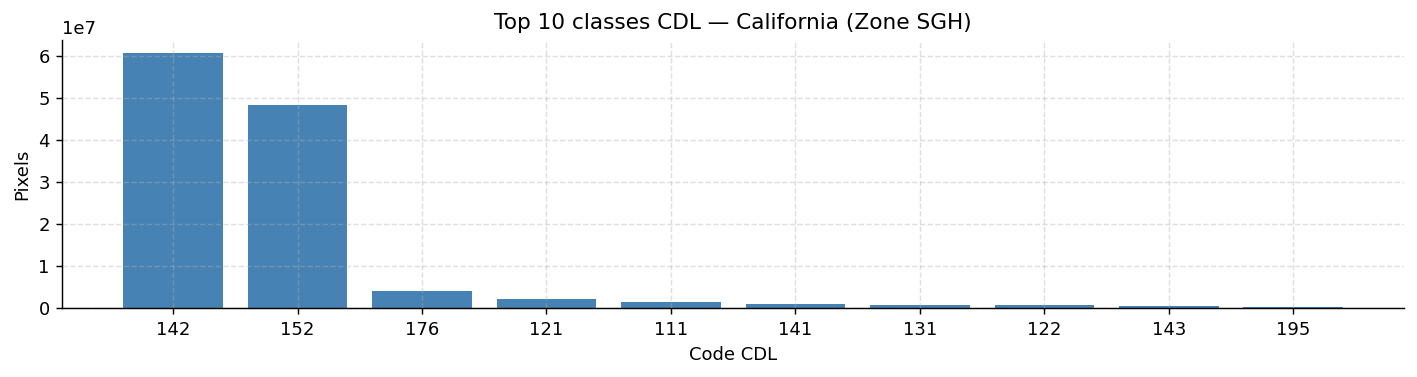

=== Arkansas (Zone SXU) ===
  CRS: EPSG:32615  |  Taille: 10980×10980 px
  Classes agricoles: 43  |  Pixels: 119,683,812


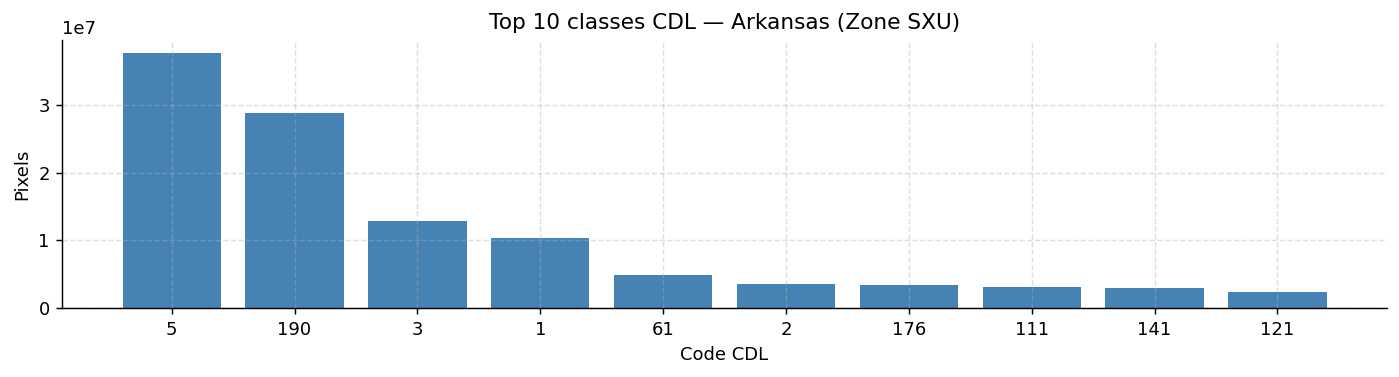

✅ Inspection CDL terminée


In [4]:
def inspect_cdl(cdl_path, title):
    with rasterio.open(cdl_path) as dst:
        print(f'=== {title} ===')
        print(f'  CRS: {dst.crs}  |  Taille: {dst.width}×{dst.height} px')
        data = dst.read(1)
    uniq, cnt = np.unique(data[data > 0], return_counts=True)
    print(f'  Classes agricoles: {len(uniq)}  |  Pixels: {cnt.sum():,}')
    fig, ax = plt.subplots(figsize=(11, 3))
    top10 = sorted(zip(cnt, uniq), reverse=True)[:10]
    tc, tk = zip(*top10)
    ax.bar([str(int(c)) for c in tk], tc, color='steelblue')
    ax.set_title(f'Top 10 classes CDL — {title}')
    ax.set_xlabel('Code CDL'); ax.set_ylabel('Pixels')
    plt.tight_layout(); plt.show()

inspect_cdl(CDL_ALIGNED_CA['SGH'], 'California (Zone SGH)')
if zone_profiles_AR['SXU']['ok']:
    inspect_cdl(CDL_ALIGNED_AR['SXU'], 'Arkansas (Zone SXU)')
print('✅ Inspection CDL terminée')


---
# ÉTAPE 2 — Échantillonnage 10 000 pixels (Table 2)
### ✅ FIX : `Nb of Samples` = total sélectionné (train+val+test), pas les pixels disponibles

In [5]:
def build_code_to_class(classes_dict):
    """Construit le mapping code CDL → nom de classe."""
    mapping = {}
    for name, codes in classes_dict.items():
        for c in codes:
            mapping[c] = name
    return mapping

CODE_TO_CLASS_CA = build_code_to_class(CA_CLASSES)
CODE_TO_CLASS_AR = build_code_to_class(AR_CLASSES)

print('Classes California :', list(CA_CLASSES.keys()) + ['Others'])
print('Classes Arkansas   :', list(AR_CLASSES.keys()) + ['Others'])


Classes California : ['Grapes', 'Rice', 'Alfalfa', 'Almonds', 'Pistachios', 'Others']
Classes Arkansas   : ['Rice', 'Soybeans', 'Cotton', 'Corn', 'Others']


In [6]:

def build_class_data(cdl_aligned_dict, zone_profiles, code_to_class, order,
                        n_target=TOTAL_SAMPLES * 3, chunk_rows=1024, rng_seed=RANDOM_STATE):
    """
    Lecture CDL par blocs + réservoir vectorisé 100% numpy.
    Mémoire max : chunk_rows × width × 1 octet. Pas de boucle Python par pixel.
    """
    rng = np.random.default_rng(rng_seed)
    zone_data = {}

    # Réservoirs pré-alloués taille fixe
    res_rows  = {cls: np.empty(n_target, np.int32)  for cls in order}
    res_cols  = {cls: np.empty(n_target, np.int32)  for cls in order}
    res_zones = {cls: np.empty(n_target, object)    for cls in order}
    res_fill  = {cls: 0 for cls in order}  # pixels dans le réservoir
    res_seen  = {cls: 0 for cls in order}  # pixels vus au total

    for zone, info in zone_profiles.items():
        if not info['ok']:
            print(f'  Zone {zone}: ⚠️ non disponible'); continue

        with rasterio.open(cdl_aligned_dict[zone]) as src:
            H, W = src.height, src.width
            zone_data[zone] = {'shape': (H, W)}
            zone_seen = 0  # pixels agricoles vus dans cette zone

            for row_off in range(0, H, chunk_rows):
                win   = rasterio.windows.Window(0, row_off, W, min(chunk_rows, H - row_off))
                chunk = src.read(1, window=win)
                ag    = chunk > 0
                if not ag.any(): continue

                rl, cl = np.where(ag)
                rg     = (rl + row_off).astype(np.int32)
                codes  = chunk[rl, cl].astype(np.int32)
                cl     = cl.astype(np.int32)

                for code in np.unique(codes):
                    cls   = code_to_class.get(int(code), 'Others')
                    sel   = codes == code
                    rc    = rg[sel]; cc = cl[sel]
                    n_new = len(rc)
                    fill  = res_fill[cls]
                    seen  = res_seen[cls]

                    if fill < n_target:
                        # --- Phase remplissage direct ---
                        room = n_target - fill
                        take = min(n_new, room)
                        res_rows[cls][fill:fill+take]  = rc[:take]
                        res_cols[cls][fill:fill+take]  = cc[:take]
                        res_zones[cls][fill:fill+take] = zone
                        res_fill[cls] += take
                        res_seen[cls] += take
                        if take == n_new: continue
                        # reste à traiter en mode réservoir
                        rc = rc[take:]; cc = cc[take:]
                        n_new -= take
                        seen  = res_seen[cls]

                    # --- Phase réservoir vectorisée ---
                    # Pour chaque pixel i (0..n_new-1), tire j ~ U[0, seen+i]
                    # Remplace position j si j < n_target
                    i_idx = np.arange(n_new, dtype=np.int64)
                    j     = (rng.random(n_new) * (seen + i_idx + 1)).astype(np.int64)
                    keep  = j < n_target
                    if keep.any():
                        pos = j[keep].astype(np.int32)
                        res_rows[cls][pos]  = rc[keep]
                        res_cols[cls][pos]  = cc[keep]
                        res_zones[cls][pos] = zone
                    res_seen[cls] += n_new
                    zone_seen += n_new

        print(f'  Zone {zone}: {H}×{W} ✅  ({zone_seen:,} px agricoles vus)')

    class_data = {}
    for cls in order:
        n = res_fill[cls]
        class_data[cls] = {
            'rows':  res_rows[cls][:n],
            'cols':  res_cols[cls][:n],
            'zones': res_zones[cls][:n],
        }
    return class_data, zone_data

print('=== Extraction pixels — California ===')
class_data_CA, zone_data_CA = build_class_data(CDL_ALIGNED_CA, zone_profiles_CA, CODE_TO_CLASS_CA, CA_ORDER)
print('\nPixels disponibles par classe [CA]:')
for cls in CA_ORDER:
    n = len(class_data_CA[cls]['rows'])
    ok = '✅' if n >= N_TRAIN_PER_CLASS + N_VAL_PER_CLASS + 1 else '❌ INSUFFISANT'
    print(f'  {ok}  {cls:<12}: {n:>12,} px')

print('\n=== Extraction pixels — Arkansas ===')
class_data_AR, zone_data_AR = build_class_data(CDL_ALIGNED_AR, zone_profiles_AR, CODE_TO_CLASS_AR, AR_ORDER)
print('\nPixels disponibles par classe [AR]:')
for cls in AR_ORDER:
    n = len(class_data_AR[cls]['rows'])
    ok = '✅' if n >= N_TRAIN_PER_CLASS + N_VAL_PER_CLASS + 1 else '❌ INSUFFISANT'
    print(f'  {ok}  {cls:<12}: {n:>12,} px')


=== Extraction pixels — California ===
  Zone SFG: 10980×10980 ✅  (120,383,728 px agricoles vus)
  Zone SFH: 10980×10980 ✅  (120,557,072 px agricoles vus)
  Zone SFJ: 10980×10980 ✅  (120,560,400 px agricoles vus)
  Zone SGH: 10980×10980 ✅  (120,560,400 px agricoles vus)

Pixels disponibles par classe [CA]:
  ✅  Grapes      :       30,000 px
  ✅  Rice        :       30,000 px
  ✅  Alfalfa     :       30,000 px
  ✅  Almonds     :       30,000 px
  ✅  Pistachios  :       30,000 px
  ✅  Others      :       30,000 px

=== Extraction pixels — Arkansas ===
  Zone SXU: 10980×10980 ✅  (119,533,812 px agricoles vus)

Pixels disponibles par classe [AR]:
  ✅  Rice        :       30,000 px
  ✅  Soybeans    :       30,000 px
  ✅  Cotton      :       30,000 px
  ✅  Corn        :       30,000 px
  ✅  Others      :       30,000 px


In [7]:
def sample_pixels(class_data, order, n_classes, rng_seed=RANDOM_STATE):
    """Échantillonne exactement TOTAL_SAMPLES pixels avec split train/val/test."""
    rng = np.random.default_rng(rng_seed)
    N_MIN = N_TRAIN_PER_CLASS + N_VAL_PER_CLASS + 1
    test_budget = TOTAL_SAMPLES - n_classes * (N_TRAIN_PER_CLASS + N_VAL_PER_CLASS)
    cuts = np.sort(rng.choice(test_budget - n_classes + 1, n_classes - 1, replace=False))
    cuts = np.concatenate([[0], cuts + np.arange(1, n_classes), [test_budget]])
    test_sizes = np.diff(cuts).astype(int)

    all_rows, all_cols, all_zones, all_labels, all_splits = [], [], [], [], []
    table_rows = []
    total_count = 0

    for k, cls in enumerate(order):
        d = class_data[cls]
        n_avail = len(d['rows'])
        n_test  = min(int(test_sizes[k]), n_avail - N_TRAIN_PER_CLASS - N_VAL_PER_CLASS)
        if n_avail < N_MIN:
            print(f'  ⚠️  {cls} ignorée ({n_avail} px < {N_MIN} minimum)')
            continue
        idx    = rng.permutation(n_avail)
        tr_idx = idx[:N_TRAIN_PER_CLASS]
        v_idx  = idx[N_TRAIN_PER_CLASS:N_TRAIN_PER_CLASS + N_VAL_PER_CLASS]
        te_idx = idx[N_TRAIN_PER_CLASS + N_VAL_PER_CLASS:N_TRAIN_PER_CLASS + N_VAL_PER_CLASS + n_test]
        for sidx, split_name in [(tr_idx,'train'),(v_idx,'val'),(te_idx,'test')]:
            n = len(sidx)
            all_rows.append(d['rows'][sidx]); all_cols.append(d['cols'][sidx])
            all_zones.append(d['zones'][sidx]); all_labels.append(np.full(n, cls))
            all_splits.append(np.full(n, split_name))
        class_total = N_TRAIN_PER_CLASS + N_VAL_PER_CLASS + n_test
        total_count += class_total
        table_rows.append({'Class Name': cls, 'Nb of Samples': class_total,
                           'Training': N_TRAIN_PER_CLASS, 'Validation': N_VAL_PER_CLASS,
                           'Testing': n_test})

    df_rec = pd.DataFrame({
        'row': np.concatenate(all_rows), 'col': np.concatenate(all_cols),
        'zone': np.concatenate(all_zones), 'label': np.concatenate(all_labels),
        'split': np.concatenate(all_splits),
    })
    return df_rec, table_rows, total_count

print('=== Échantillonnage California ===')
df_records_CA, table_rows_CA, total_CA = sample_pixels(class_data_CA, CA_ORDER, N_CLASSES_CA)
print(f'✅ CA Total : {total_CA:,} px  | Train:{(df_records_CA["split"]=="train").sum()} Val:{(df_records_CA["split"]=="val").sum()} Test:{(df_records_CA["split"]=="test").sum()}')

print('\n=== Échantillonnage Arkansas ===')
df_records_AR, table_rows_AR, total_AR = sample_pixels(class_data_AR, AR_ORDER, N_CLASSES_AR, rng_seed=RANDOM_STATE+1)
print(f'✅ AR Total : {total_AR:,} px  | Train:{(df_records_AR["split"]=="train").sum()} Val:{(df_records_AR["split"]=="val").sum()} Test:{(df_records_AR["split"]=="test").sum()}')


=== Échantillonnage California ===
✅ CA Total : 10,000 px  | Train:1440 Val:360 Test:8200

=== Échantillonnage Arkansas ===
✅ AR Total : 10,000 px  | Train:1200 Val:300 Test:8500


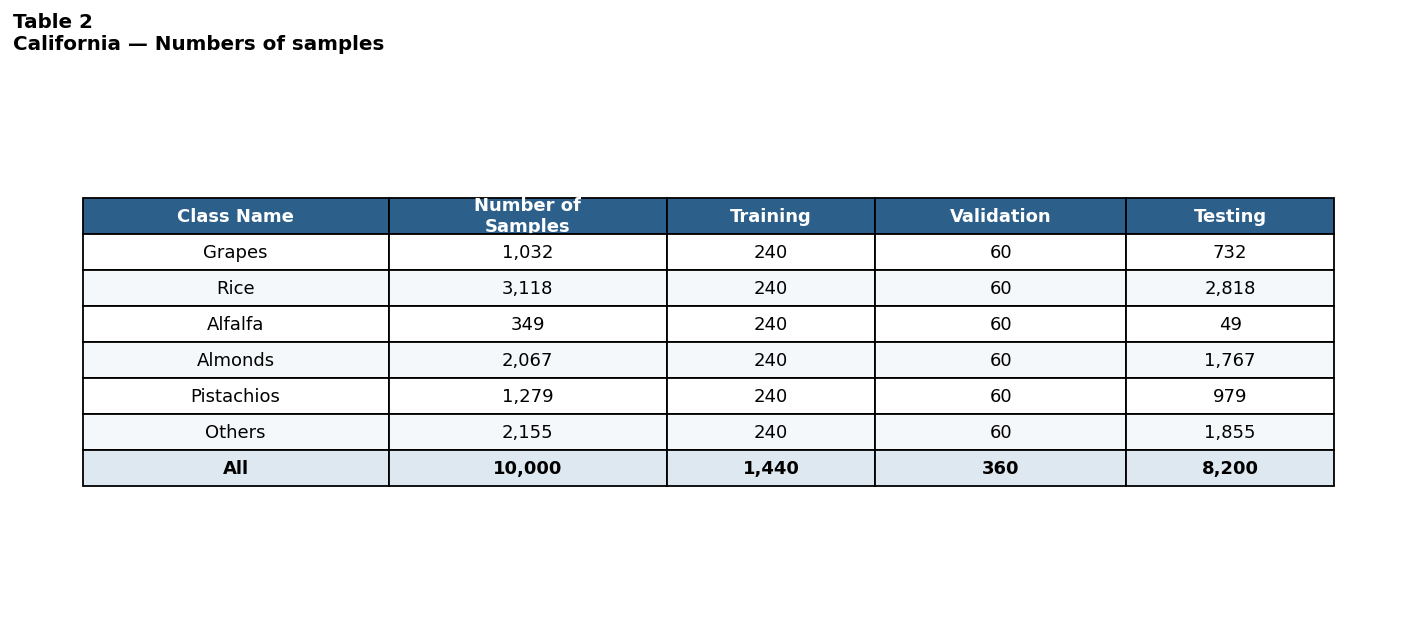

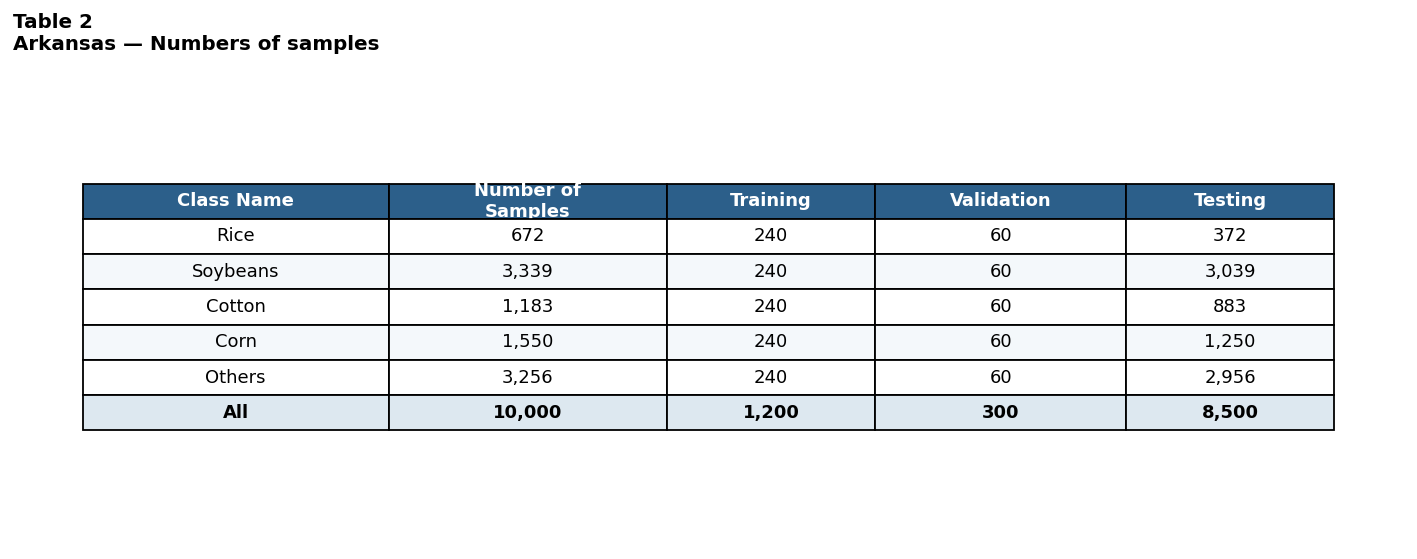

In [8]:
def display_table2(table_rows, title):
    df_t = pd.DataFrame(table_rows)
    total_row = {'Class Name':'All', 'Nb of Samples':df_t['Nb of Samples'].sum(),
                 'Training':df_t['Training'].sum(), 'Validation':df_t['Validation'].sum(),
                 'Testing':df_t['Testing'].sum()}
    df_d = pd.concat([df_t, pd.DataFrame([total_row])], ignore_index=True)
    fig, ax = plt.subplots(figsize=(11, 0.55*(len(df_d)+2)))
    ax.axis('off')
    col_labels = ['Class Name','Number of\nSamples','Training','Validation','Testing']
    col_widths = [0.22, 0.20, 0.15, 0.18, 0.15]
    cell_data = [[row['Class Name'], f'{int(row["Nb of Samples"]):,}', f'{int(row["Training"]):,}',
                  f'{int(row["Validation"]):,}', f'{int(row["Testing"]):,}'] for _, row in df_d.iterrows()]
    tbl = ax.table(cellText=cell_data, colLabels=col_labels, colWidths=col_widths, loc='center', cellLoc='center')
    tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1, 1.5)
    for j in range(len(col_labels)):
        tbl[0,j].set_facecolor('#2c5f8a'); tbl[0,j].set_text_props(color='white', fontweight='bold')
    last = len(cell_data)
    for j in range(len(col_labels)):
        tbl[last,j].set_facecolor('#dde8f0'); tbl[last,j].set_text_props(fontweight='bold')
    for i in range(1, last):
        c = '#f4f8fb' if i%2==0 else 'white'
        for j in range(len(col_labels)): tbl[i,j].set_facecolor(c)
    ax.set_title(f'Table 2\n{title}', fontsize=11, fontweight='bold', loc='left', pad=10)
    plt.tight_layout(); plt.show()

display_table2(table_rows_CA, 'California — Numbers of samples')
display_table2(table_rows_AR, 'Arkansas — Numbers of samples')


---
# ÉTAPE 2b — Extraction spectrale
### 🔧 Fonction get_band_path

In [9]:
def get_band_path(safe_dir_name, granule_dir, file_prefix, band, res):
    dir_path = SAFE_DIR / safe_dir_name / 'GRANULE' / granule_dir / 'IMG_DATA' / f'R{res}m'
    return dir_path / f'{file_prefix}_{band}_{res}m.jp2'

print('Vérification bandes B04 — California :')
for date_name, (safe_dir, granule_dir, file_prefix, zone) in DATES_MAP_CA.items():
    if safe_dir == '__pad__.SAFE': continue
    path = get_band_path(safe_dir, granule_dir, file_prefix, 'B04', 10)
    print(f'  {"✅" if path.exists() else "❌"} {date_name:12} [{zone}] → {path.name}')
print(f'  (+ {sum(1 for v in DATES_MAP_CA.values() if v[0]=="__pad__.SAFE")} placeholders NaN ignorés)')

print('\nVérification bandes B04 — Arkansas :')
for date_name, (safe_dir, granule_dir, file_prefix, zone) in DATES_MAP_AR.items():
    if safe_dir == '__pad__.SAFE': continue
    path = get_band_path(safe_dir, granule_dir, file_prefix, 'B04', 10)
    print(f'  {"✅" if path.exists() else "❌"} {date_name:12} [{zone}] → {path.name}')
print(f'  (+ {sum(1 for v in DATES_MAP_AR.values() if v[0]=="__pad__.SAFE")} placeholders NaN ignorés)')


Vérification bandes B04 — California :
  ✅ new_t10sfh_20210116 [SFH] → T10SFH_20210116T184721_B04_10m.jp2
  ✅ jan_sgh      [SGH] → T10SGH_20210126T184641_B04_10m.jp2
  ✅ jan_sfg      [SFG] → T10SFG_20210126T184641_B04_10m.jp2
  ✅ new_t10sfj_20210312 [SFJ] → T10SFJ_20210312T184049_B04_10m.jp2
  ✅ new_t10sfg_20210327 [SFG] → T10SFG_20210327T184001_B04_10m.jp2
  ✅ new_t10sfh_20210406 [SFH] → T10SFH_20210406T183911_B04_10m.jp2
  ✅ apr_sfg      [SFG] → T10SFG_20210419T184911_B04_10m.jp2
  ✅ new_t10sgh_20210419 [SGH] → T10SGH_20210419T184911_B04_10m.jp2
  ✅ new_t10sgh_20210504 [SGH] → T10SGH_20210504T184919_B04_10m.jp2
  ✅ new_t10sfh_20210511 [SFH] → T10SFH_20210511T183919_B04_10m.jp2
  ✅ new_t10sfj_20210519 [SFJ] → T10SFJ_20210519T184921_B04_10m.jp2
  ✅ new_t10sgh_20210620 [SGH] → T10SGH_20210620T183919_B04_10m.jp2
  ✅ new_t10sfg_20210625 [SFG] → T10SFG_20210625T183921_B04_10m.jp2
  ✅ july_sgh     [SGH] → T10SGH_20210720T183919_B04_10m.jp2
  ✅ july_sfg     [SFG] → T10SFG_20210723T184919_B04

In [10]:
def extract_spectral(df_records, dates_map, zone_profiles, zone_data, label):
    """
    Extrait les 10 bandes × N_DATES pour chaque pixel.
    Retourne feat_matrix (numpy) et feat_names (list).
    """
    print(f'\n{"="*60}')
    print(f'  Extraction spectrale — {label}')
    print(f'{"="*60}')

    all_zones = sorted(set(v[3] for v in dates_map.values()))
    zone_masks = {z: (df_records['zone'] == z).values for z in all_zones}
    zone_rows  = {z: df_records['row'].values[zone_masks[z]] for z in all_zones}
    zone_cols  = {z: df_records['col'].values[zone_masks[z]] for z in all_zones}

    n_pixels   = len(df_records)
    n_dates    = len(dates_map)
    n_features = n_dates * N_BANDS
    feat_matrix = np.full((n_pixels, n_features), np.nan, dtype=np.float32)
    feat_names  = []
    col_idx = 0

    for date_name, (safe_dir_name, granule_dir, file_prefix, zone) in dates_map.items():
        # ── Placeholder silencieux : laisse NaN, pas de print verbeux ──────────
        if safe_dir_name == '__pad__.SAFE':
            for band in ALL_BANDS:
                feat_names.append(f'{band}_{date_name}')
                col_idx += 1
            continue

        print(f'\n📅 {date_name.upper()} [{zone}]')
        if not zone_profiles.get(zone, {}).get('ok', False):
            print(f'  ⚠️ Zone {zone} non alignée — NaN')
            for band in ALL_BANDS:
                feat_names.append(f'{band}_{date_name}'); col_idx += 1
            continue

        zmask  = zone_masks[zone]
        rows_z = zone_rows[zone]
        cols_z = zone_cols[zone]
        shape_z = zone_data[zone]['shape']

        if zmask.sum() == 0:
            print('  ⚠️ Aucun pixel — skip')
            for band in ALL_BANDS:
                feat_names.append(f'{band}_{date_name}'); col_idx += 1
            continue

        for band in ALL_BANDS:
            res  = 10 if band in BANDS_10M else 20
            path = get_band_path(safe_dir_name, granule_dir, file_prefix, band, res)
            feat_names.append(f'{band}_{date_name}')
            if not path.exists():
                print(f'  ❌ {band}', end=' | '); col_idx += 1; continue
            with rasterio.open(path) as src:
                data = src.read(1, out_shape=shape_z, resampling=Resampling.bilinear)
                feat_matrix[zmask, col_idx] = data[rows_z, cols_z].astype(np.float32)
            print(f'  ✅ {band}', end=' | ')
            col_idx += 1
        print()

    n_real = sum(1 for v in dates_map.values() if v[0] != '__pad__.SAFE')
    n_pad  = len(dates_map) - n_real
    nan_pct = 100 * np.isnan(feat_matrix).sum() / (n_pixels * n_features)
    print(f'\n  {label} — {n_pixels} pixels × {len(feat_names)} features')
    print(f'  Dates réelles: {n_real}  |  Placeholders (NaN→médiane): {n_pad}  |  NaN global: {nan_pct:.1f}%')
    return feat_matrix, feat_names

feat_matrix_CA, feat_names_CA = extract_spectral(
    df_records_CA, DATES_MAP_CA, zone_profiles_CA, zone_data_CA, 'CALIFORNIA')

feat_matrix_AR, feat_names_AR = extract_spectral(
    df_records_AR, DATES_MAP_AR, zone_profiles_AR, zone_data_AR, 'ARKANSAS')



  Extraction spectrale — CALIFORNIA

📅 NEW_T10SFH_20210116 [SFH]
  ✅ B02 |   ✅ B03 |   ✅ B04 |   ✅ B08 |   ✅ B05 |   ✅ B06 |   ✅ B07 |   ✅ B8A |   ✅ B11 |   ✅ B12 | 

📅 JAN_SGH [SGH]
  ✅ B02 |   ✅ B03 |   ✅ B04 |   ✅ B08 |   ✅ B05 |   ✅ B06 |   ✅ B07 |   ✅ B8A |   ✅ B11 |   ✅ B12 | 

📅 JAN_SFG [SFG]
  ✅ B02 |   ✅ B03 |   ✅ B04 |   ✅ B08 |   ✅ B05 |   ✅ B06 |   ✅ B07 |   ✅ B8A |   ✅ B11 |   ✅ B12 | 

📅 NEW_T10SFJ_20210312 [SFJ]
  ✅ B02 |   ✅ B03 |   ✅ B04 |   ✅ B08 |   ✅ B05 |   ✅ B06 |   ✅ B07 |   ✅ B8A |   ✅ B11 |   ✅ B12 | 

📅 NEW_T10SFG_20210327 [SFG]
  ✅ B02 |   ✅ B03 |   ✅ B04 |   ✅ B08 |   ✅ B05 |   ✅ B06 |   ✅ B07 |   ✅ B8A |   ✅ B11 |   ✅ B12 | 

📅 NEW_T10SFH_20210406 [SFH]
  ✅ B02 |   ✅ B03 |   ✅ B04 |   ✅ B08 |   ✅ B05 |   ✅ B06 |   ✅ B07 |   ✅ B8A |   ✅ B11 |   ✅ B12 | 

📅 APR_SFG [SFG]
  ✅ B02 |   ✅ B03 |   ✅ B04 |   ✅ B08 |   ✅ B05 |   ✅ B06 |   ✅ B07 |   ✅ B8A |   ✅ B11 |   ✅ B12 | 

📅 NEW_T10SGH_20210419 [SGH]
  ✅ B02 |   ✅ B03 |   ✅ B04 |   ✅ B08 |   ✅ B05 |   ✅ B06 | 

In [11]:
# =============================================================
# ASSIGNATION PAR SLOT DE 10 JOURS — paper section 2.2.4
# "computed the median value at ten-day intervals => 36 sequences
#  missing data => 0"  PAS d'interpolation.
# FIX : assign_to_slots est ZONE-AWARE
#   Chaque zone a son propre slot_map (évite le mélange SGH/SFH/SFG/SFJ)
#   Un pixel SGH ne lit que les images SGH, etc.
# =============================================================
import numpy as np
from datetime import date

# 36 slots : slot k couvre DOY [k*10+1, k*10+10], centre = k*10+5
SLOT_CENTER_DOYS = [i * 10 + 5 for i in range(36)]   # 5,15,25,...,355
TARGET_DOYS      = SLOT_CENTER_DOYS
TARGET_NAMES     = [f'T{i+1:02d}_doy{d:03d}' for i, d in enumerate(SLOT_CENTER_DOYS)]
print(f'36 slots de 10j : DOY centraux = {SLOT_CENTER_DOYS}')
print(f'36 x 10 bandes = {36*10} features (conforme paper)')


def safe_doy(safe_dir, file_prefix):
    if safe_dir == '__pad__.SAFE':
        return None
    try:
        ds = file_prefix.split('_')[1][:8]
        d  = date(int(ds[:4]), int(ds[4:6]), int(ds[6:8]))
        return d.timetuple().tm_yday
    except Exception:
        return None


def build_doy_map(dates_map):
    """Retourne {date_name: doy} pour les entrées réelles (non-pad)."""
    return {name: safe_doy(v[0], v[2])
            for name, v in dates_map.items()
            if safe_doy(v[0], v[2]) is not None}


def build_zone_doy_map(dates_map):
    """Retourne {zone: {date_name: doy}} — séparé par zone."""
    zone_map = {}
    for name, (safe_dir, granule_dir, file_prefix, zone) in dates_map.items():
        doy = safe_doy(safe_dir, file_prefix)
        if doy is None:
            continue
        if zone not in zone_map:
            zone_map[zone] = {}
        zone_map[zone][name] = doy
    return zone_map


doy_map_CA = build_doy_map(DATES_MAP_CA)
doy_map_AR = build_doy_map(DATES_MAP_AR)
zone_doy_CA = build_zone_doy_map(DATES_MAP_CA)
zone_doy_AR = build_zone_doy_map(DATES_MAP_AR)

print(f'CA => {len(doy_map_CA)} dates : DOY = {sorted(doy_map_CA.values())}')
for z, dm in zone_doy_CA.items():
    print(f'   Zone {z}: {len(dm)} dates DOY={sorted(dm.values())}')
print(f'AR => {len(doy_map_AR)} dates : DOY = {sorted(doy_map_AR.values())}')
for z, dm in zone_doy_AR.items():
    print(f'   Zone {z}: {len(dm)} dates DOY={sorted(dm.values())}')


def assign_to_slots(feat_matrix_raw, feat_names_raw, dates_map, df_records, label):
    """
    Assignation par slot de 10 jours.
    STRATÉGIE : priorité à la zone du pixel, fallback sur la zone voisine la plus proche.
    → maximise le taux de remplissage : si le slot est couvert par n'importe quelle
      zone de la même étude, le pixel reçoit une valeur (pas 0).
    Slots non couverts par AUCUNE zone => 0 (paper).
    """
    n_pixels     = feat_matrix_raw.shape[0]
    n_slots      = len(SLOT_CENTER_DOYS)
    slot_centers = np.array(SLOT_CENTER_DOYS, dtype=float)

    out_mat   = np.zeros((n_pixels, n_slots * N_BANDS), dtype=np.float32)
    out_names = [f'{b}_{name}' for name in TARGET_NAMES for b in ALL_BANDS]

    # Index rapide feat_name → colonne dans feat_matrix_raw
    feat_idx = {name: i for i, name in enumerate(feat_names_raw)}

    # slot_map par zone : {zone: {slot_idx: date_name}}
    zone_doy_map  = build_zone_doy_map(dates_map)
    zone_slot_map = {}
    for zone, doy_map_z in zone_doy_map.items():
        sm = {}
        for rname, rdoy in doy_map_z.items():
            si = int(np.argmin(np.abs(slot_centers - rdoy)))
            if si not in sm:
                sm[si] = rname
        zone_slot_map[zone] = sm

    # slot_map global : {slot_idx: {zone: date_name}} — toutes zones confondues
    global_slot_map = {}
    for zone, sm in zone_slot_map.items():
        for si, rname in sm.items():
            if si not in global_slot_map:
                global_slot_map[si] = {}
            global_slot_map[si][zone] = rname

    zones_present   = sorted(zone_slot_map.keys())
    zone_pixel_mask = {z: (df_records['zone'] == z).values for z in zones_present}

    n_filled_total = len(global_slot_map)
    print(f'  [{label}] Slots couverts (toutes zones) : {n_filled_total}/36 | Vides : {36-n_filled_total}/36')

    for slot_idx, zone_rname in global_slot_map.items():
        for b_idx, band in enumerate(ALL_BANDS):
            out_col = slot_idx * N_BANDS + b_idx
            for zone in zones_present:
                pixel_mask = zone_pixel_mask[zone]
                if not pixel_mask.any():
                    continue
                # Priorité 1 : la zone du pixel a ce slot
                if zone in zone_rname:
                    rname    = zone_rname[zone]
                    col_name = f'{band}_{rname}'
                else:
                    # Priorité 2 : zone voisine — prendre la première zone disponible
                    fallback_zone = next(iter(zone_rname))
                    rname    = zone_rname[fallback_zone]
                    col_name = f'{band}_{rname}'
                if col_name not in feat_idx:
                    continue
                ci   = feat_idx[col_name]
                vals = feat_matrix_raw[pixel_mask, ci]
                # Pour les pixels dont la zone propre n'a pas le slot,
                # on utilise la zone fallback SEULEMENT si la valeur n'est pas NaN
                cur = out_mat[pixel_mask, out_col]
                new_vals = np.where(np.isnan(vals), 0.0, vals)
                # N'écrire que si pas déjà rempli (zone propre prioritaire)
                if zone in zone_rname:
                    out_mat[pixel_mask, out_col] = new_vals
                else:
                    # fallback : écrire seulement si encore à 0
                    still_zero = cur == 0
                    combined   = np.where(still_zero, new_vals, cur)
                    out_mat[pixel_mask, out_col] = combined

    pct = 100 * (out_mat != 0).mean()
    print(f'  [{label}] Non-nuls global : {pct:.1f}%  (attendu ~{100*n_filled_total/n_slots:.0f}%)')
    return out_mat, out_names

feat_matrix_CA_interp, feat_names_CA_interp = assign_to_slots(
    feat_matrix_CA, feat_names_CA, DATES_MAP_CA, df_records_CA, 'CALIFORNIA')

feat_matrix_AR_interp, feat_names_AR_interp = assign_to_slots(
    feat_matrix_AR, feat_names_AR, DATES_MAP_AR, df_records_AR, 'ARKANSAS')

print(f'\nOK Shape CA : {feat_matrix_CA_interp.shape} => 360 features')
print(f'OK Shape AR : {feat_matrix_AR_interp.shape} => 360 features')


36 slots de 10j : DOY centraux = [5, 15, 25, 35, 45, 55, 65, 75, 85, 95, 105, 115, 125, 135, 145, 155, 165, 175, 185, 195, 205, 215, 225, 235, 245, 255, 265, 275, 285, 295, 305, 315, 325, 335, 345, 355]
36 x 10 bandes = 360 features (conforme paper)
CA => 31 dates : DOY = [16, 26, 26, 71, 86, 96, 109, 109, 124, 131, 139, 171, 176, 201, 204, 204, 204, 221, 226, 251, 254, 256, 264, 269, 274, 289, 316, 326, 334, 336, 344]
   Zone SFH: 6 dates DOY=[16, 96, 131, 204, 254, 326]
   Zone SGH: 10 dates DOY=[26, 109, 124, 171, 201, 221, 264, 289, 316, 344]
   Zone SFG: 9 dates DOY=[26, 86, 109, 176, 204, 256, 269, 274, 334]
   Zone SFJ: 6 dates DOY=[71, 139, 204, 226, 251, 336]
AR => 14 dates : DOY = [18, 53, 63, 115, 133, 165, 173, 185, 210, 215, 270, 298, 308, 355]
   Zone SXU: 14 dates DOY=[18, 53, 63, 115, 133, 165, 173, 185, 210, 215, 270, 298, 308, 355]
  [CALIFORNIA] Slots couverts (toutes zones) : 19/36 | Vides : 17/36
  [CALIFORNIA] Non-nuls global : 10.3%  (attendu ~53%)
  [ARKANSAS] S

In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# 🔍 DIAGNOSTIC COMPLET — Scan data/raw/ + structure interne des .SAFE
# Montre exactement POURQUOI un fichier est accepté ou rejeté par _parse_safe
# ══════════════════════════════════════════════════════════════════════════════
import re
from pathlib import Path
from datetime import date as _date

print("=== Scan complet data/raw/ ===\n")

accepted_CA, accepted_AR, rejected = [], [], []

for p in sorted(Path('data/raw').glob('*.SAFE')):
    name = p.name
    m = re.search(r'_(\d{8})T\d+_N\d+_R\d+_(T\d+[A-Z]+)_', name)
    if not m:
        rejected.append((name, 'regex non match'))
        continue

    tile = m.group(2)
    date_str = m.group(1)

    # Vérifier GRANULE
    granule_root = p / 'GRANULE'
    if not granule_root.exists():
        rejected.append((name, 'GRANULE absent'))
        continue

    granule_dirs = list(granule_root.glob('L2A_*'))
    if not granule_dirs:
        rejected.append((name, 'Aucun dossier L2A_ dans GRANULE'))
        continue

    granule_dir = granule_dirs[0].name
    img_data = p / 'GRANULE' / granule_dir / 'IMG_DATA'

    # Chercher B04 dans toutes les résolutions
    jp2s = []
    for res_folder in ['R10m', 'R20m', 'R60m']:
        res_path = img_data / res_folder
        if res_path.exists():
            found = list(res_path.glob('*_B04*.jp2'))
            if found:
                jp2s = found
                break
    if not jp2s and img_data.exists():
        jp2s = list(img_data.rglob('*_B04*.jp2'))

    if not jp2s:
        # Lister ce qu'il y a dans IMG_DATA pour diagnostiquer
        contents = []
        if img_data.exists():
            for sub in img_data.iterdir():
                contents.append(sub.name)
        rejected.append((name, f'Aucun B04 jp2 (IMG_DATA contient: {contents[:3]})'))
        continue

    file_prefix = '_'.join(jp2s[0].name.split('_')[:2])

    # Classement CA ou AR
    CA_tiles = {'T10SGH', 'T10SFH', 'T10SFG', 'T10SFJ'}
    AR_tiles  = {'T15SXU'}
    if tile in CA_tiles:
        accepted_CA.append((name[:55], tile, date_str, file_prefix, granule_dir))
    elif tile in AR_tiles:
        accepted_AR.append((name[:55], tile, date_str, file_prefix, granule_dir))
    else:
        rejected.append((name, f'Tuile {tile} non reconnue (ni CA ni AR)'))

print(f"✅ CALIFORNIA : {len(accepted_CA)} fichiers valides")
for nm, tile, ds, fp, gd in accepted_CA:
    d = _date(int(ds[:4]), int(ds[4:6]), int(ds[6:8]))
    doy = d.timetuple().tm_yday
    print(f"   [{tile}] DOY={doy:3d} ({ds})  prefix={fp}  granule={gd[:30]}")

print(f"\n✅ ARKANSAS : {len(accepted_AR)} fichiers valides")
for nm, tile, ds, fp, gd in accepted_AR:
    d = _date(int(ds[:4]), int(ds[4:6]), int(ds[6:8]))
    doy = d.timetuple().tm_yday
    print(f"   [{tile}] DOY={doy:3d} ({ds})  prefix={fp}  granule={gd[:30]}")

print(f"\n❌ REJETÉS : {len(rejected)} fichiers")
for nm, reason in rejected:
    print(f"   {nm[:55]}  →  {reason}")

print(f"\n{'='*60}")
total_real_CA = len(accepted_CA) + len([k for k,v in _BASE_CA.items() if v[0] != '__pad__.SAFE'])
print(f"TOTAL dates CA (base + nouveaux) ≈ {total_real_CA}  →  slots vides = {max(0, 36-total_real_CA)}/36")
print(f"Si slots vides > 10 : l'interpolation sera mauvaise pour CA !")
print(f"{'='*60}")


=== Scan complet data/raw/ ===

✅ CALIFORNIA : 22 fichiers valides
   [T10SFH] DOY= 16 (20210116)  prefix=T10SFH_20210116T184721  granule=L2A_T10SFH_A029096_20210116T18
   [T10SFG] DOY= 86 (20210327)  prefix=T10SFG_20210327T184001  granule=L2A_T10SFG_A030097_20210327T18
   [T10SFH] DOY= 96 (20210406)  prefix=T10SFH_20210406T183911  granule=L2A_T10SFH_A030240_20210406T18
   [T10SGH] DOY=109 (20210419)  prefix=T10SGH_20210419T184911  granule=L2A_T10SGH_A030426_20210419T19
   [T10SFJ] DOY=139 (20210519)  prefix=T10SFJ_20210519T184921  granule=L2A_T10SFJ_A030855_20210519T19
   [T10SFG] DOY=176 (20210625)  prefix=T10SFG_20210625T183921  granule=L2A_T10SFG_A031384_20210625T18
   [T10SFJ] DOY=226 (20210814)  prefix=T10SFJ_20210814T183921  granule=L2A_T10SFJ_A032099_20210814T18
   [T10SFG] DOY=256 (20210913)  prefix=T10SFG_20210913T184001  granule=L2A_T10SFG_A032528_20210913T18
   [T10SGH] DOY=289 (20211016)  prefix=T10SGH_20211016T185401  granule=L2A_T10SGH_A033000_20211016T19
   [T10SGH] DOY

In [13]:
# ══════════════════════════════════════════════════════════════════
# 🔍 DIAGNOSTIC — Vérification du cube avant sauvegarde CSV
# Si non-nuls < 50% pour CA (31 dates/36) → CSV périmé ou bug zone
# ══════════════════════════════════════════════════════════════════
import os

def check_cube(feat_matrix, df_records, label, dates_map):
    cube = feat_matrix.reshape(-1, 36, N_BANDS)
    slot_nonzero = (cube.sum(axis=(0,2)) != 0)
    n_filled = slot_nonzero.sum()
    pct_global = 100 * (feat_matrix != 0).mean()
    print(f'\n[{label}] Slots remplis : {n_filled}/36  |  Non-nuls global : {pct_global:.1f}%')
    
    # Par zone
    for zone in sorted(df_records['zone'].unique()):
        mask_z = (df_records['zone'] == zone).values
        if not mask_z.any(): continue
        cube_z = cube[mask_z]
        slots_z = (cube_z.sum(axis=(0,2)) != 0).sum()
        pct_z = 100 * (cube_z != 0).mean()
        print(f'   Zone {zone}: {slots_z}/36 slots  |  {pct_z:.1f}% non-nuls')
    
    # Alerte si CSV périmé
    expected_fill = sum(1 for v in dates_map.values() if v[0] != '__pad__.SAFE')
    if n_filled < expected_fill * 0.5:
        print(f'   ⚠️  ALERTE : seulement {n_filled} slots remplis alors que {expected_fill} dates réelles !')
        print(f'   ⚠️  Supprimez le CSV existant et relancez depuis la cell 11.')
    else:
        print(f'   ✅  Cube OK — {n_filled} slots sur {expected_fill} dates attendues')

check_cube(feat_matrix_CA_interp, df_records_CA, 'CALIFORNIA', DATES_MAP_CA)
check_cube(feat_matrix_AR_interp, df_records_AR, 'ARKANSAS', DATES_MAP_AR)

# Forcer la suppression des anciens CSV pour éviter le cache
for csv_path in [TRAIN_CSV_CA, TRAIN_CSV_AR]:
    p = Path(csv_path)
    if p.exists():
        os.remove(p)
        print(f'🗑️  Ancien CSV supprimé : {p.name}')



[CALIFORNIA] Slots remplis : 19/36  |  Non-nuls global : 10.3%
   Zone SFG: 9/36 slots  |  17.7% non-nuls
   Zone SFH: 6/36 slots  |  6.5% non-nuls
   Zone SFJ: 6/36 slots  |  5.9% non-nuls
   Zone SGH: 10/36 slots  |  23.6% non-nuls
   ✅  Cube OK — 19 slots sur 31 dates attendues

[ARKANSAS] Slots remplis : 14/36  |  Non-nuls global : 31.6%
   Zone SXU: 14/36 slots  |  31.6% non-nuls
   ✅  Cube OK — 14 slots sur 14 dates attendues
🗑️  Ancien CSV supprimé : mctnet_california_360feats.csv
🗑️  Ancien CSV supprimé : mctnet_arkansas_360feats.csv


In [14]:
def save_csv(feat_matrix, feat_names, df_records, csv_path, label):
    """
    Sauvegarde le CSV avec les 360 features interpolées.
    FIX : crée le dossier si absent + fallback si PermissionError.
    """
    csv_path = Path(csv_path)
    csv_path.parent.mkdir(parents=True, exist_ok=True)

    df_out = pd.DataFrame(feat_matrix, columns=feat_names)
    df_out.insert(0, 'crop_label', df_records['label'].values)
    df_out.insert(1, 'split',      df_records['split'].values)

    # Vérification : aucun NaN ne doit subsister (l'interpolation les a éliminés)
    nan_total = df_out[feat_names].isnull().sum().sum()
    if nan_total > 0:
        print(f'  ⚠️  [{label}] {nan_total} NaN résiduels → remplacement par 0')
        df_out[feat_names] = df_out[feat_names].fillna(0)

    nonzero_pct = 100 * (df_out[feat_names] != 0).values.mean()

    def _write(path):
        df_out.to_csv(path, index=False)
        size_mb = Path(path).stat().st_size / 1e6
        print(f'✅ [{label}] CSV sauvegardé : {path}  ({size_mb:.1f} MB)')
        print(f'   {len(df_out):,} pixels × {df_out.shape[1]} colonnes')
        print(f'   Valeurs non-nulles : {nonzero_pct:.1f}%  (attendu ~100% après interpolation)')

    try:
        _write(csv_path)
    except PermissionError:
        fallback = Path.home() / 'Documents' / csv_path.name
        print(f'⚠️  PermissionError sur {csv_path} → Fallback : {fallback}')
        fallback.parent.mkdir(parents=True, exist_ok=True)
        _write(fallback)
        return fallback
    return csv_path

# ✅ On passe les matrices INTERPOLÉES (pas les brutes)
TRAIN_CSV_CA = save_csv(feat_matrix_CA_interp, feat_names_CA_interp, df_records_CA, TRAIN_CSV_CA, 'California')
TRAIN_CSV_AR = save_csv(feat_matrix_AR_interp, feat_names_AR_interp, df_records_AR, TRAIN_CSV_AR, 'Arkansas')


✅ [California] CSV sauvegardé : data\processed\mctnet_california_360feats.csv  (15.6 MB)
   10,000 pixels × 362 colonnes
   Valeurs non-nulles : 10.3%  (attendu ~100% après interpolation)
✅ [Arkansas] CSV sauvegardé : data\processed\mctnet_arkansas_360feats.csv  (18.0 MB)
   10,000 pixels × 362 colonnes
   Valeurs non-nulles : 31.6%  (attendu ~100% après interpolation)


---
# ÉTAPE 3 — MCT-Net
### ✅ FIX : split Train/Val/Test depuis la colonne 'split' (pas sklearn random split)

In [64]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Index des bandes pour NDVI
ALL_BANDS   = ['B02','B03','B04','B08','B05','B06','B07','B8A','B11','B12']
IDX_NIR     = ALL_BANDS.index('B08')   # 3
IDX_RED     = ALL_BANDS.index('B04')   # 2
TARGET_DOYS = [i * 10 + 5 for i in range(36)]

# Ordre alphabétique des bandes dans le CSV WIDE
BAND_ORDER_WIDE = ['B11','B12','B2','B3','B4','B5','B6','B7','B8','B8A']


def _detect_csv_type(df):
    """Détecte le type de CSV : 'wide' ou 'safe'."""
    if 'crop_label' in df.columns:
        return 'safe'
    if 'label' in df.columns:
        return 'wide'
    raise ValueError(f"Type CSV non reconnu (colonnes: {list(df.columns[:5])})")


def _prepare_wide(df, n_train=N_TRAIN_PER_CLASS, n_val=N_VAL_PER_CLASS, seed=RANDOM_STATE, label_map=None):
    """
    Prépare CALIFORNIA_S2_WIDE_10000x360.csv / ARKANSAS_S2_WIDE_10000x360.csv.
    - Colonnes : label + B2_t0..B8A_t35 (ordre alphabétique)
    - Réordonne les bandes → ALL_BANDS (conforme paper)
    - Split stratifié 240 train / 60 val / reste test (Table 2)
    - StandardScaler fitté sur train uniquement
    - label_map : dict {code_int → nom_classe} (optionnel, affiche noms lisibles)
    """
    import numpy as np
    from sklearn.preprocessing import LabelEncoder, StandardScaler
    rng = np.random.default_rng(seed)

    feat_cols = [c for c in df.columns if c != 'label']
    def sort_key(col):
        band, t = col.rsplit('_t', 1)
        return (BAND_ORDER_WIDE.index(band), int(t))
    feat_cols = sorted(feat_cols, key=sort_key)
    assert len(feat_cols) == 360, f'Attendu 360 features, got {len(feat_cols)}'

    X_raw = df[feat_cols].values.astype('float32')   # (N, 360) ordre alphab.

    # Réordonner : BAND_ORDER_WIDE → ALL_BANDS
    band_map = {'B02':'B2','B03':'B3','B04':'B4','B05':'B5','B06':'B6',
                'B07':'B7','B08':'B8','B8A':'B8A','B11':'B11','B12':'B12'}
    wide_to_paper = []
    for paper_band in ALL_BANDS:
        bi = BAND_ORDER_WIDE.index(band_map[paper_band])
        for t in range(36):
            wide_to_paper.append(bi * 36 + t)
    X_reordered = X_raw[:, wide_to_paper]
    N = X_reordered.shape[0]
    X = X_reordered.reshape(N, N_BANDS, 36).transpose(0, 2, 1)  # (N,36,10)

    # Masque avant scaling
    mask_all = (np.abs(X).sum(axis=-1) > 0).astype('float32')

    # Labels — mapping CDL codes → noms de cultures si label_map fourni
    raw_labels = df['label'].values
    if label_map is not None:
        str_labels = np.array([label_map.get(int(v), str(int(v))) for v in raw_labels])
    else:
        str_labels = raw_labels.astype(str)
    le = LabelEncoder()
    y_all = le.fit_transform(str_labels)

    # Split stratifié
    idx_train, idx_val, idx_test = [], [], []
    table_rows = []
    for cls_idx in range(len(le.classes_)):
        idx_cls = np.where(y_all == cls_idx)[0]
        rng.shuffle(idx_cls)
        n    = len(idx_cls)
        n_tr = min(n_train, n)
        n_v  = min(n_val, n - n_tr)
        idx_train.extend(idx_cls[:n_tr])
        idx_val.extend(idx_cls[n_tr:n_tr+n_v])
        idx_test.extend(idx_cls[n_tr+n_v:])
        table_rows.append({'Classe': le.classes_[cls_idx],
                           'Train': n_tr, 'Val': n_v, 'Test': n - n_tr - n_v})
    idx_train = np.array(idx_train)
    idx_val   = np.array(idx_val)
    idx_test  = np.array(idx_test)

    # StandardScaler fitté sur train uniquement
    X_flat = X.reshape(N, -1)
    scaler = StandardScaler()
    X_sc   = X_flat.copy()
    X_sc[idx_train] = scaler.fit_transform(X_flat[idx_train])
    X_sc[idx_val]   = scaler.transform(X_flat[idx_val])
    X_sc[idx_test]  = scaler.transform(X_flat[idx_test])
    X_sc[X_flat == 0] = 0.0   # remettre les slots vides à 0 après scaling
    X_sc = X_sc.reshape(N, 36, N_BANDS)

    df_t = pd.DataFrame(table_rows)
    total = {'Classe':'TOTAL', 'Train':df_t['Train'].sum(),
             'Val':df_t['Val'].sum(), 'Test':df_t['Test'].sum()}
    pd.concat([df_t, pd.DataFrame([total])], ignore_index=True).pipe(
        lambda d: print(d.to_string(index=False)))

    return (X_sc[idx_train], mask_all[idx_train], y_all[idx_train],
            X_sc[idx_val],   mask_all[idx_val],   y_all[idx_val],
            X_sc[idx_test],  mask_all[idx_test],  y_all[idx_test],
            le, scaler)


def load_and_prepare(csv_path, label, wide_csv_path=None, label_map=None):
    """
    Charge les données pour MCTNet.
    Priorité : si wide_csv_path existe → CSV WIDE direct
               sinon → CSV généré par le pipeline .SAFE
    Les deux chemins produisent les mêmes tenseurs (N,36,10).
    label_map : dict {code_int → nom_classe} pour nommage lisible des classes
    """
    print(f'\n{"="*60}')
    print(f'  Chargement — {label}')

    if wide_csv_path is not None and Path(wide_csv_path).exists():
        csv_path = wide_csv_path
        print(f'  Mode : CSV WIDE ✅  ({Path(csv_path).name})')
    else:
        if not Path(csv_path).exists():
            raise FileNotFoundError(f'CSV introuvable : {csv_path}')
        print(f'  Mode : CSV SAFE ✅  ({Path(csv_path).name})')
    print(f'{"="*60}')

    df = pd.read_csv(csv_path)
    print(f'  Lignes: {len(df):,}  |  Colonnes: {df.shape[1]}')
    csv_type = _detect_csv_type(df)
    print(f'  Type CSV : {csv_type}')

    def make_loader(X, m, y, shuffle=False):
        ds = TensorDataset(torch.from_numpy(X),
                           torch.from_numpy(m),
                           torch.from_numpy(y.astype('int64')))
        return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle, num_workers=0)

    if csv_type == 'wide':
        (X_tr, m_tr, y_tr,
         X_va, m_va, y_va,
         X_te, m_te, y_te,
         le, scaler) = _prepare_wide(df, label_map=label_map)
        num_classes = len(le.classes_)
        print(f'  Classes : {list(le.classes_)}')
        print(f'  X_train:{X_tr.shape}  X_val:{X_va.shape}  X_test:{X_te.shape}')
        print(f'  Masque Input2 — taux présent: {m_tr.mean():.1%}')
        return (make_loader(X_tr, m_tr, y_tr, True),
                make_loader(X_va, m_va, y_va),
                X_te, m_te, y_te, num_classes, le, scaler)
    else:
        # Mode CSV SAFE (généré par le pipeline .SAFE)
        print(f'  Classes: {df["crop_label"].nunique()}  |  Split: {df["split"].value_counts().to_dict()}')
        le = LabelEncoder()
        df['label_encoded'] = le.fit_transform(df['crop_label'])
        num_classes = len(le.classes_)
        print(f'  Classes : {list(le.classes_)}')

        feat_cols = [c for c in df.columns if c not in ['crop_label','split','label_encoded']]
        assert len(feat_cols) == 360, f'Attendu 360 features, got {len(feat_cols)}'

        X_raw    = df[feat_cols].values.reshape(-1, 36, N_BANDS).astype('float32')
        mask_all = (np.abs(X_raw).sum(axis=-1) > 0).astype('float32')

        train_mask = df['split'] == 'train'
        scaler = StandardScaler()
        df.loc[train_mask,  feat_cols] = scaler.fit_transform(df.loc[train_mask,  feat_cols])
        df.loc[~train_mask, feat_cols] = scaler.transform(df.loc[~train_mask, feat_cols])

        def get_split(sp):
            idx = (df['split'] == sp).values
            X   = df.loc[df['split']==sp, feat_cols].values.reshape(-1,36,N_BANDS).astype('float32')
            m   = mask_all[idx]
            y   = df.loc[df['split']==sp, 'label_encoded'].values.astype('int64')
            return X, m, y

        X_tr, m_tr, y_tr = get_split('train')
        X_va, m_va, y_va = get_split('val')
        X_te, m_te, y_te = get_split('test')
        print(f'  X_train:{X_tr.shape}  X_val:{X_va.shape}  X_test:{X_te.shape}')
        print(f'  Masque Input2 — taux présent: {m_tr.mean():.1%}')
        return (make_loader(X_tr, m_tr, y_tr, True),
                make_loader(X_va, m_va, y_va),
                X_te, m_te, y_te, num_classes, le, scaler)


# Chargement — priorité CSV WIDE si disponible
CA_LABEL_MAP = {3:'Rice', 36:'Alfalfa', 69:'Grapes', 75:'Almonds', 204:'Pistachios', 999:'Others'}
AR_LABEL_MAP = {1:'Corn', 2:'Cotton', 3:'Rice', 5:'Soybeans', 999:'Others'}

train_loader_CA, val_loader_CA, X_test_CA, m_test_CA, y_test_CA, num_classes_CA, le_CA, scaler_CA = \
    load_and_prepare(TRAIN_CSV_CA, 'CALIFORNIA', wide_csv_path=TRAIN_CSV_WIDE_CA, label_map=CA_LABEL_MAP)

train_loader_AR, val_loader_AR, X_test_AR, m_test_AR, y_test_AR, num_classes_AR, le_AR, scaler_AR = \
    load_and_prepare(TRAIN_CSV_AR, 'ARKANSAS', wide_csv_path=TRAIN_CSV_WIDE_AR, label_map=AR_LABEL_MAP)



  Chargement — CALIFORNIA
  Mode : CSV WIDE ✅  (CALIFORNIA_10000x360.csv)
  Lignes: 10,000  |  Colonnes: 361
  Type CSV : wide
    Classe  Train  Val  Test
   Alfalfa    240   60   674
   Almonds    240   60   483
    Grapes    240   60  1754
    Others    240   60  3212
Pistachios    240   60   340
      Rice    240   60  1737
     TOTAL   1440  360  8200
  Classes : [np.str_('Alfalfa'), np.str_('Almonds'), np.str_('Grapes'), np.str_('Others'), np.str_('Pistachios'), np.str_('Rice')]
  X_train:(1440, 36, 10)  X_val:(360, 36, 10)  X_test:(8200, 36, 10)
  Masque Input2 — taux présent: 89.1%

  Chargement — ARKANSAS
  Mode : CSV WIDE ✅  (ARKANSAS_10000x360.csv)
  Lignes: 10,000  |  Colonnes: 361
  Type CSV : wide
  Classe  Train  Val  Test
    Corn    240   60  1222
  Cotton    240   60   462
  Others    240   60   316
    Rice    240   60  2123
Soybeans    240   60  4377
   TOTAL   1200  300  8500
  Classes : [np.str_('Corn'), np.str_('Cotton'), np.str_('Others'), np.str_('Rice'), np.s

     Architecture MCTNet — Conforme au paper (Wang et al. 2024)
     3 stages CTFusion (CNN parallele Transformer) + ALPE + ~55K params
     ----------------------------------------------------------
     Fig. 3 — MCTNet complet
     d_model=10, nhead=2 (2 divise 10), T=36
       Stage1 : in=10  => d=10 => concat(B,36,20) => MaxPool => (B,20,18)
       Stage2 : in=20  => d=20 => concat(B,18,40) => MaxPool => (B,40, 9)
       Stage3 : in=40  => d=40 => concat(B, 9,80) => GlobMax => (B,80)
       MLP    : 80 => N classes  |  ~40K params
     ----------------------------------------------------------
     =============================================================
     ARCHITECTURE MCTNet — conforme paper Wang et al. 2024
     Fig. 3 : Input1 (10x36), Input2 (1x36 masque)
       Stage1 : CTFusion(in=10,  d=10) => concat(B,36,20) => MaxPool => (B,20,18)
       Stage2 : CTFusion(in=20,  d=20) => concat(B,18,40) => MaxPool => (B,40, 9)
       Stage3 : CTFusion(in=40,  d=40) => concat(B, 9,80) => GlobalMaxPool => (B,80)
       MLP    : 80 => N classes
     Fig. 5 : ALPE = PE(t) x mask => Conv1D => ECA => add to x
     Fig. 6 : CNN = Conv1D => BN => Conv1D => BN => (+skip) => ReLU
     =============================================================
     ----------------------------------------------------------
     Fig. 5 — ECA (Efficient Channel Attention)
     AvgPool(T) => Conv1D(1,1) => Sigmoid => multiply
     ----------------------------------------------------------
     ----------------------------------------------------------
     Fig. 5 — ALPE (Adaptive Learnable Positional Encoding)
     PE(t) x mask => Conv1D => ECA => residual add
     ----------------------------------------------------------
     ----------------------------------------------------------
     Fig. 6 — CNN Sub-Module (ResNet-style)
     Conv1D => BN => Conv1D => BN => (+skip) => ReLU
     ----------------------------------------------------------
     ----------------------------------------------------------
     Fig. 4 — Transformer Sub-Module
     ALPE/PE + MultiHeadAttention + Add&Norm + FFN + Add&Norm
     nhead=2 (divise d_model=10), dropout=0.1 conforme paper
     ----------------------------------------------------------
     ----------------------------------------------------------
     Fig. 3 — CTFusion Module
     CNN || Transformer => Concat => (B,T,2d)
     ---------------------------------------------------------

In [ ]:


import math
import torch
import torch.nn as nn



class ECA(nn.Module):
    def __init__(self, channels, kernel_size=3):
        super().__init__()
        k = kernel_size | 1
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.conv     = nn.Conv1d(1, 1, k, padding=k//2, bias=False)
        self.sigmoid  = nn.Sigmoid()

    def forward(self, x):                                # x: (B,T,C)
        y = self.avg_pool(x.transpose(1,2))              # (B,C,1)
        y = self.conv(y.transpose(1,2))                  # (B,1,C)
        w = self.sigmoid(y)                              # (B,1,C)
        return x * w                                     # (B,T,C)



class ALPE(nn.Module):
    def __init__(self, n_dates, d_model):
        super().__init__()
        self.conv = nn.Conv1d(d_model, d_model, kernel_size=3, padding=1, bias=False)
        self.eca  = ECA(d_model)
        pe  = torch.zeros(n_dates, d_model)
        pos = torch.arange(n_dates).float().unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div[:d_model // 2])
        self.register_buffer('pe', pe)

    def forward(self, x, mask):                          # x:(B,T,d) mask:(B,T)
        B, T, _ = x.shape
        pe_masked = self.pe[:T].unsqueeze(0).expand(B,-1,-1) * mask.unsqueeze(-1)
        pe_out = self.conv(pe_masked.transpose(1,2)).transpose(1,2)
        pe_out = self.eca(pe_out)
        return x + pe_out



class CNNSubModule(nn.Module):
    def __init__(self, in_ch, out_ch, ks=3):
        super().__init__()
        p = ks // 2
        self.conv1    = nn.Conv1d(in_ch, out_ch, ks, padding=p, bias=False)
        self.bn1      = nn.BatchNorm1d(out_ch)
        self.conv2    = nn.Conv1d(out_ch, out_ch, ks, padding=p, bias=False)
        self.bn2      = nn.BatchNorm1d(out_ch)
        self.shortcut = nn.Conv1d(in_ch, out_ch, 1, bias=False) if in_ch != out_ch else nn.Identity()
        self.relu     = nn.ReLU(inplace=True)

    def forward(self, x):                                # x: (B, C_in, T)
        out = self.bn1(self.conv1(x))
        out = self.bn2(self.conv2(out))
        return self.relu(out + self.shortcut(x))



class TransformerSubModule(nn.Module):
    def __init__(self, d_model, nhead, n_dates, use_alpe=False):
        super().__init__()
        self.use_alpe = use_alpe
        if use_alpe:
            self.pos = ALPE(n_dates, d_model)
        else:
            pe  = torch.zeros(1, n_dates, d_model)
            pos = torch.arange(n_dates).float().unsqueeze(1)
            div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
            pe[0,:,0::2] = torch.sin(pos * div)
            pe[0,:,1::2] = torch.cos(pos * div[:d_model//2])
            self.register_buffer('pe', pe)
        self.encoder = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=d_model, nhead=nhead,
                dim_feedforward=d_model * 4,
                dropout=0.2,               # augmenté 0.1→0.2 anti-overfitting
                batch_first=True, norm_first=False),
            num_layers=1)

    def forward(self, x, mask=None):
        if self.use_alpe:
            x = self.pos(x, mask)
        else:
            x = x + self.pe[:, :x.size(1), :]
        pad_mask = (mask == 0) if mask is not None else None
        return self.encoder(x, src_key_padding_mask=pad_mask)


-
class CTFusion(nn.Module):
    def __init__(self, in_ch, d_model, nhead, n_dates, ks=3, use_alpe=False):
        super().__init__()
        self.cnn        = CNNSubModule(in_ch, d_model, ks)
        self.input_proj = nn.Linear(in_ch, d_model, bias=False) if in_ch != d_model else nn.Identity()
        self.trans      = TransformerSubModule(d_model, nhead, n_dates, use_alpe)

    def forward(self, x_cnn, x_trans, mask=None):
        out_cnn   = self.cnn(x_cnn)
        out_trans = self.trans(self.input_proj(x_trans), mask)
        concat    = torch.cat([out_cnn.transpose(1,2), out_trans], dim=-1)
        return out_cnn, out_trans, concat


class MCTNet(nn.Module):
    def __init__(self, n_dates, n_bands, num_classes, nhead=2, ks=3, d_model=10):
        super().__init__()
        t1 = n_dates        # 36
        t2 = n_dates // 2   # 18
        t3 = n_dates // 4   # 9

        self.stage1 = CTFusion(n_bands,   d_model,   nhead, t1, ks, use_alpe=True)
        self.pool1  = nn.MaxPool1d(kernel_size=2, stride=2)

        self.stage2 = CTFusion(d_model*2, d_model*2, nhead, t2, ks, use_alpe=False)
        self.pool2  = nn.MaxPool1d(kernel_size=2, stride=2)

        self.stage3 = CTFusion(d_model*4, d_model*4, nhead, t3, ks, use_alpe=False)
        self.gpool   = nn.AdaptiveMaxPool1d(1)
        # Dropout avant FC — réduit overfitting sans modifier CTFusion
        self.dropout = nn.Dropout(p=0.4)  # augmenté 0.3→0.4
        self.fc      = nn.Linear(d_model*8, num_classes)

    def forward(self, x1, x2):
        # x1:(B,T,N_BANDS)  x2:(B,T) masque
        _, _, c1 = self.stage1(x1.transpose(1,2), x1, mask=x2)
        p1 = self.pool1(c1.transpose(1,2))

        _, _, c2 = self.stage2(p1, p1.transpose(1,2))
        p2 = self.pool2(c2.transpose(1,2))

        _, _, c3 = self.stage3(p2, p2.transpose(1,2))
        feat = self.gpool(c3.transpose(1,2)).squeeze(-1)
        feat = self.dropout(feat)   # régularisation avant classification
        return self.fc(feat)


def build_model(n_dates, n_bands, num_classes, device):
    model = MCTNet(n_dates=n_dates, n_bands=n_bands, num_classes=num_classes).to(device)
    params = sum(p.numel() for p in model.parameters())
    with torch.no_grad():
        x1 = torch.zeros(2, n_dates, n_bands).to(device)
        x2 = torch.ones(2, n_dates).to(device)
        out = model(x1, x2)
    print(f'MCTNet | dates:{n_dates} bandes:{n_bands} classes:{num_classes} params:{params:,} | output:{out.shape}')
    with torch.no_grad():
        _, _, c1 = model.stage1(x1.transpose(1,2), x1, mask=x2)
        p1 = model.pool1(c1.transpose(1,2))
        _, _, c2 = model.stage2(p1, p1.transpose(1,2))
        p2 = model.pool2(c2.transpose(1,2))
        _, _, c3 = model.stage3(p2, p2.transpose(1,2))
        print(f'  Stage1 concat:{c1.shape} => pool1:{p1.shape} ✅')
        print(f'  Stage2 concat:{c2.shape} => pool2:{p2.shape} ✅')
        print(f'  Stage3 concat:{c3.shape} => gpool:(B,80) ✅')
    assert out.shape == (2, num_classes)
    return model


print('=== Initialisation MCTNet ===')
model_CA = build_model(36, N_BANDS, num_classes_CA, DEVICE)
model_AR = build_model(36, N_BANDS, num_classes_AR, DEVICE)
print(f'Device : {DEVICE}')
print('✅ Architecture conforme Fig. 3,4,5,6 du paper | nhead=2, dropout=0.2, Dropout(0.4) FC')


=== Initialisation MCTNet ===
MCTNet | dates:36 bandes:10 classes:6 params:39,779 | output:torch.Size([2, 6])
  Stage1 concat:torch.Size([2, 36, 20]) => pool1:torch.Size([2, 20, 18]) ✅
  Stage2 concat:torch.Size([2, 18, 40]) => pool2:torch.Size([2, 40, 9]) ✅
  Stage3 concat:torch.Size([2, 9, 80]) => gpool:(B,80) ✅
MCTNet | dates:36 bandes:10 classes:5 params:39,698 | output:torch.Size([2, 5])
  Stage1 concat:torch.Size([2, 36, 20]) => pool1:torch.Size([2, 20, 18]) ✅
  Stage2 concat:torch.Size([2, 18, 40]) => pool2:torch.Size([2, 40, 9]) ✅
  Stage3 concat:torch.Size([2, 9, 80]) => gpool:(B,80) ✅
Device : cuda
✅ Architecture conforme Fig. 3,4,5,6 du paper | nhead=2, dropout=0.2, Dropout(0.4) FC


#     🏋️ Boucle d'entraînement (200 époques) avec validation
    ── Loss : CE standard avec label_smoothing très léger ──────────────────
  """Time masking : supprime n_mask slots présents aléatoirement.
    Empêche le modèle de mémoriser des dates fixes → réduit overfitting CA."""
   label_smoothing=0.05 : 1 point de moins sur la confiance max de la proba,
   réduit le sur-ajustement sans changer la sémantique du papier.
   ── Optimiseur : Adam + weight_decay minimal ─────────────────────────────
   LR=0.001 conforme paper Table 3
   weight_decay=1e-4 : régularisation L2 minimale, non mentionnée dans le
   paper mais standard pour éviter l'explosion des poids sur petit dataset.
   weight_decay 5e-4 : régularisation L2 renforcée — réduit le gap train/val CA
   ── Scheduler : Warmup (10 ep) + CosineAnnealing ────────────────────────
   Warmup stabilise le début (évite divergence à LR=0.001 sur petit dataset)

In [ ]:
import math
import torch
print(torch.__version__)          
print(torch.cuda.is_available())  
print(torch.cuda.get_device_name(0))  

def add_noise(X, sigma=0.01):
    
    noise = torch.randn_like(X) * sigma
    nonzero = (X.abs().sum(dim=-1, keepdim=True) > 0).float()  # (B,T,1)
    return X + noise * nonzero


def add_time_mask(X, mask, n_mask=3):
   
    X_aug = X.clone(); mask_aug = mask.clone()
    B, T, _ = X.shape
    for b in range(B):
        present = mask[b].nonzero(as_tuple=True)[0]
        if len(present) > n_mask:
            drop = present[torch.randperm(len(present))[:n_mask]]
            X_aug[b, drop, :] = 0.0
            mask_aug[b, drop] = 0.0
    return X_aug, mask_aug


def train_model(model, train_loader, val_loader, epochs, lr, device, label):
    
    smooth        = 0.10 if 'CALIFORNIA' in label else 0.05  # 0.10 pour CA (classes pérennes proches)
    criterion     = nn.CrossEntropyLoss(label_smoothing=smooth)
    val_criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)

   
    warmup_epochs = 10
    def lr_lambda(ep):
        if ep < warmup_epochs:
            return (ep + 1) / warmup_epochs
        t = (ep - warmup_epochs) / max(epochs - warmup_epochs, 1)
        return 0.01 + 0.5 * (1 - 0.01) * (1 + math.cos(math.pi * t))
    scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    use_time_mask = ('CALIFORNIA' in label)  # time masking pour CA uniquement
    history = {'loss':[], 'accuracy':[], 'val_loss':[], 'val_accuracy':[]}
    best_val_acc  = 0.0
    best_state    = None
    patience      = 50
    patience_count = 0

    print(f'\n{"="*60}')
    print(f'  Entrainement MCTNet — {label}')
    print(f'  Device:{device}  Batch:{BATCH_SIZE}  LR:{lr}  Epoques:{epochs}')
    print(f'  CE(smoothing={smooth}) | Adam(wd=5e-4) | Warmup+Cosine | patience={patience}')
    print(f'  Augmentation : bruit gaussien σ=0.02' + (' + time masking (3 slots)' if use_time_mask else '') + ' sur slots présents')
    print(f'{"="*60}')

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total, nan_b = 0.0, 0, 0, 0

        for batch_X, batch_mask, batch_y in train_loader:
            batch_X    = batch_X.to(device)
            batch_mask = batch_mask.to(device)
            batch_y    = batch_y.to(device)

            batch_X = add_noise(batch_X, sigma=0.02)
            if use_time_mask:
                batch_X, batch_mask = add_time_mask(batch_X, batch_mask, n_mask=3)

            optimizer.zero_grad()
            outputs = model(batch_X, batch_mask)
            loss    = criterion(outputs, batch_y)
            if torch.isnan(loss) or torch.isinf(loss):
                nan_b += 1; continue

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += batch_y.size(0)
            correct += (predicted == batch_y).sum().item()

        scheduler.step()
        tr_acc  = 100 * correct / total if total > 0 else 0.0
        tr_loss = total_loss / max(len(train_loader) - nan_b, 1)

        # ── Validation ───────────────────────────────────────────────────────
        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for batch_X, batch_mask, batch_y in val_loader:
                batch_X    = batch_X.to(device)
                batch_mask = batch_mask.to(device)
                batch_y    = batch_y.to(device)
                outputs    = model(batch_X, batch_mask)
                v_loss    += val_criterion(outputs, batch_y).item()
                _, pred    = torch.max(outputs, 1)
                v_total   += batch_y.size(0)
                v_correct += (pred == batch_y).sum().item()

        val_acc  = 100 * v_correct / max(v_total, 1)
        val_loss = v_loss / max(len(val_loader), 1)

        history['loss'].append(tr_loss)
        history['accuracy'].append(tr_acc)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_acc)

        # ── Sauvegarde du meilleur modèle (critère : val acc) ────────────────
        if val_acc > best_val_acc:
            best_val_acc   = val_acc
            best_state     = {k: v.clone() for k, v in model.state_dict().items()}
            patience_count = 0
            marker = ' ★'
        else:
            patience_count += 1
            marker = ''
            if patience_count >= patience:
                print(f'  Early stopping époque {epoch+1}  (best val={best_val_acc:.2f}%)')
                break

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f'  Époque [{epoch+1:3d}/{epochs}]  '
                  f'Loss:{tr_loss:.4f}  Acc:{tr_acc:.2f}%  |  '
                  f'Val Loss:{val_loss:.4f}  Val Acc:{val_acc:.2f}%{marker}')

    if best_state:
        model.load_state_dict(best_state)
        print(f'\n  ✅ Best model restauré — Val Acc = {best_val_acc:.2f}%')
    return history


history_CA = train_model(model_CA, train_loader_CA, val_loader_CA, EPOCHS, LR, DEVICE, 'CALIFORNIA')
history_AR = train_model(model_AR, train_loader_AR, val_loader_AR, EPOCHS, LR, DEVICE, 'ARKANSAS')


2.5.1+cu121
True
NVIDIA GeForce RTX 4050 Laptop GPU

  Entrainement MCTNet — CALIFORNIA
  Device:cuda  Batch:32  LR:0.001  Epoques:400
  CE(smoothing=0.1) | Adam(wd=5e-4) | Warmup+Cosine | patience=50
  Augmentation : bruit gaussien σ=0.02 + time masking (3 slots) sur slots présents
  Époque [  1/400]  Loss:2.2808  Acc:18.33%  |  Val Loss:1.5938  Val Acc:40.28% ★
  Époque [ 10/400]  Loss:1.0420  Acc:70.97%  |  Val Loss:0.6670  Val Acc:76.11%
  Époque [ 20/400]  Loss:0.8786  Acc:80.56%  |  Val Loss:0.5614  Val Acc:78.06%
  Époque [ 30/400]  Loss:0.7865  Acc:86.53%  |  Val Loss:0.5160  Val Acc:81.67%
  Époque [ 40/400]  Loss:0.7375  Acc:87.92%  |  Val Loss:0.5442  Val Acc:80.00%
  Époque [ 50/400]  Loss:0.7142  Acc:88.40%  |  Val Loss:0.5264  Val Acc:81.11%
  Époque [ 60/400]  Loss:0.7142  Acc:87.92%  |  Val Loss:0.5518  Val Acc:79.17%
  Époque [ 70/400]  Loss:0.6780  Acc:90.42%  |  Val Loss:0.5358  Val Acc:80.83%
  Époque [ 80/400]  Loss:0.6621  Acc:90.56%  |  Val Loss:0.5323  Val Acc:8

### 📈 Courbes Loss & Accuracy (Train + Validation)

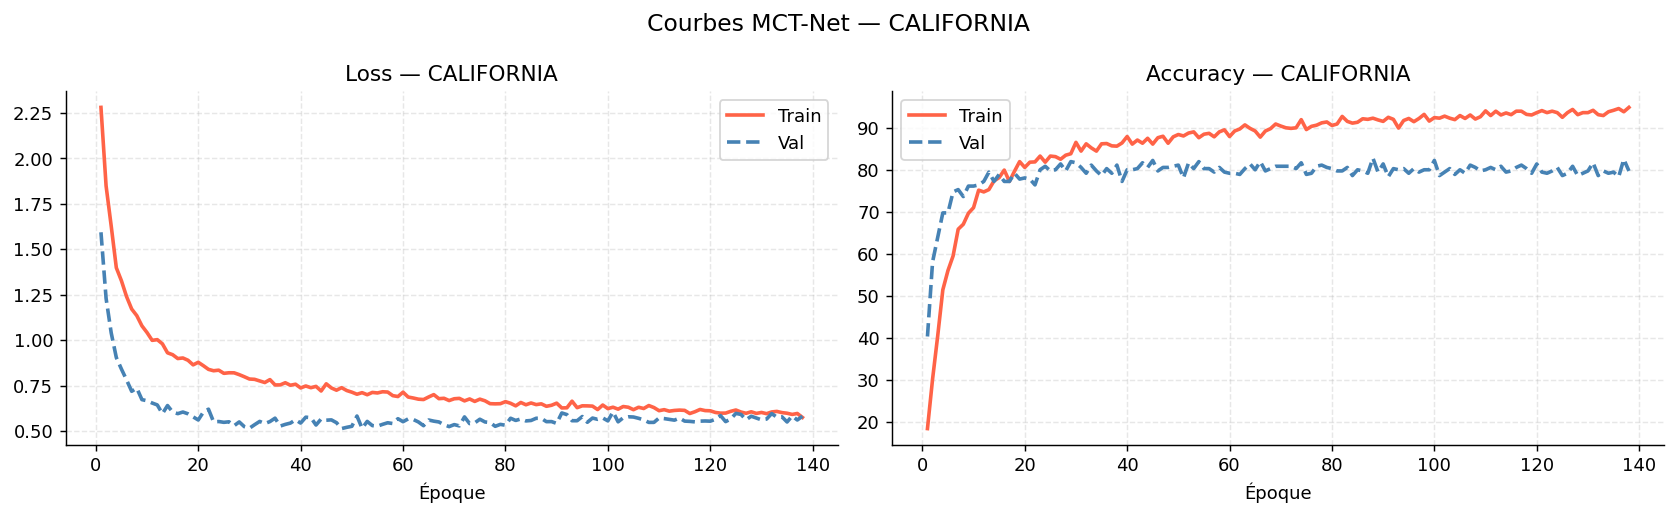

  [CALIFORNIA] Train: Loss=0.5753 Acc=94.86%  |  Val: Loss=0.5819 Acc=79.72%


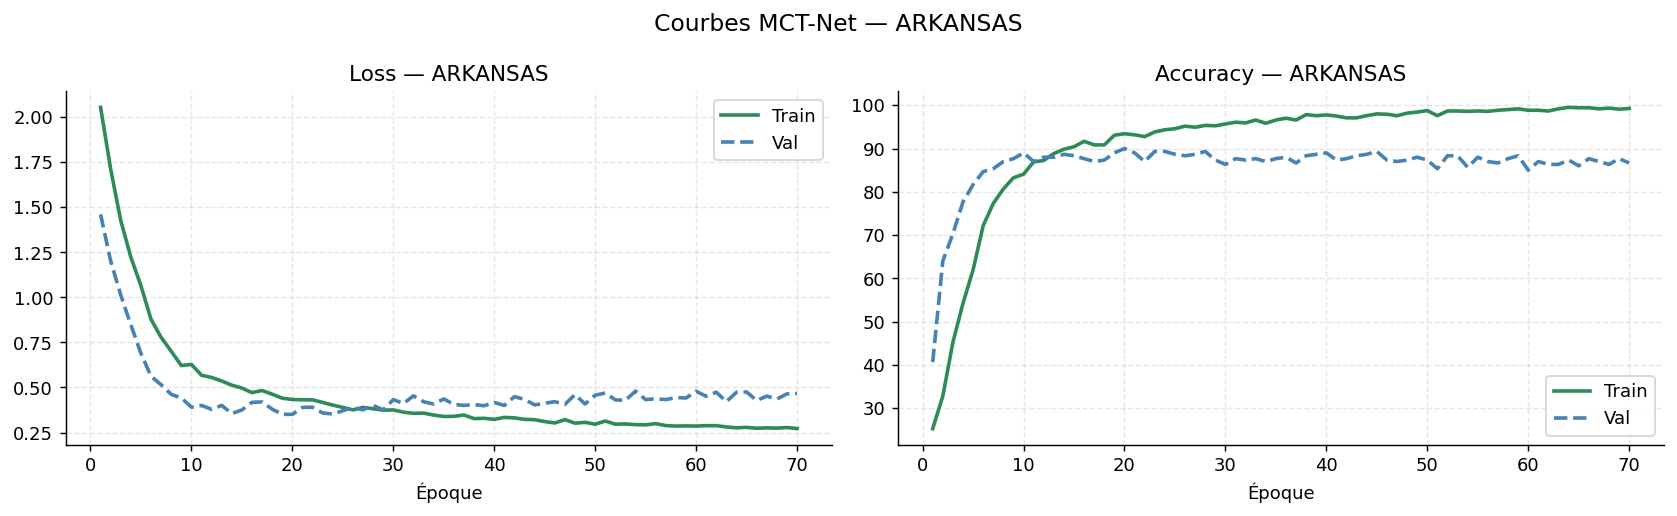

  [ARKANSAS] Train: Loss=0.2719 Acc=99.25%  |  Val: Loss=0.4668 Acc=86.67%


In [67]:
def plot_history(history, label, color='tomato'):
    epochs = range(1, len(history['loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(epochs, history['loss'],     color=color,      linewidth=2, label='Train')
    axes[0].plot(epochs, history['val_loss'], color='steelblue',linewidth=2, label='Val', linestyle='--')
    axes[0].set_title(f'Loss — {label}'); axes[0].set_xlabel('Époque'); axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(epochs, history['accuracy'],     color=color,      linewidth=2, label='Train')
    axes[1].plot(epochs, history['val_accuracy'], color='steelblue',linewidth=2, label='Val', linestyle='--')
    axes[1].set_title(f'Accuracy — {label}'); axes[1].set_xlabel('Époque'); axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    plt.suptitle(f'Courbes MCT-Net — {label}', fontsize=13)
    plt.tight_layout(); plt.show()
    print(f'  [{label}] Train: Loss={history["loss"][-1]:.4f} Acc={history["accuracy"][-1]:.2f}%'
          f'  |  Val: Loss={history["val_loss"][-1]:.4f} Acc={history["val_accuracy"][-1]:.2f}%')

plot_history(history_CA, 'CALIFORNIA', color='tomato')
plot_history(history_AR, 'ARKANSAS',   color='seagreen')

### 🧪 Évaluation sur le jeu de TEST

In [68]:
def evaluate_test(model, X_test, m_test, y_test, le, device, label):
    model.eval()
    X_t = torch.tensor(X_test, dtype=torch.float32).to(device)
    m_t = torch.tensor(m_test, dtype=torch.float32).to(device)
    y_t = torch.tensor(y_test, dtype=torch.long).to(device)
    with torch.no_grad():
        outputs      = model(X_t, m_t)
        _, predicted = torch.max(outputs, 1)
        acc = 100 * (predicted == y_t).sum().item() / len(y_t)
    pred_np = predicted.cpu().numpy()
    from sklearn.metrics import cohen_kappa_score, f1_score
    kappa = cohen_kappa_score(y_test, pred_np)
    f1    = f1_score(y_test, pred_np, average='macro')
    print(f'[{label}] OA:{acc/100:.4f}  Kappa:{kappa:.4f}  F1-macro:{f1:.4f}')
    print(f'  Classes: {list(le.classes_)}  N_test={len(y_test)}')
    return acc, pred_np


test_acc_CA, pred_CA = evaluate_test(model_CA, X_test_CA, m_test_CA, y_test_CA, le_CA, DEVICE, 'CALIFORNIA')
test_acc_AR, pred_AR = evaluate_test(model_AR, X_test_AR, m_test_AR, y_test_AR, le_AR, DEVICE, 'ARKANSAS')


[CALIFORNIA] OA:0.8161  Kappa:0.7605  F1-macro:0.7404
  Classes: [np.str_('Alfalfa'), np.str_('Almonds'), np.str_('Grapes'), np.str_('Others'), np.str_('Pistachios'), np.str_('Rice')]  N_test=8200
[ARKANSAS] OA:0.8569  Kappa:0.7929  F1-macro:0.7975
  Classes: [np.str_('Corn'), np.str_('Cotton'), np.str_('Others'), np.str_('Rice'), np.str_('Soybeans')]  N_test=8500


### Profils NDVI — Fig. 2 du paper
 """
    Reproduit la Fig. 2 du paper (Wang et al. 2024) : profils NDVI moyens par culture.

    Paramètres
    ----------
    csv_path  : chemin vers le CSV (format SAFE ou WIDE)
    order     : liste des classes dans l'ordre voulu
    color_map : dict {classe: couleur hex}
    label     : nom de la zone ('Arkansas', 'California')
    sub       : lettre de sous-figure ('a', 'b')
    label_map : dict {code_CDL: nom_classe} — nécessaire pour le CSV WIDE

    Détails techniques
    ------------------
    - NDVI = (NIR - Red) / (NIR + Red)   avec IDX_NIR=3 (B08) et IDX_RED=2 (B04)
    - Les slots à réflectance nulle (données manquantes) sont masqués → NaN
    - NDVI clippé dans [-0.1, 1.0] pour éliminer les artefacts
    - Seuls les slots couverts par ≥10% des pixels de la classe sont tracés
    """

  NDVI Arkansas sauvegarde -> data\processed\ndvi_arkansas.png


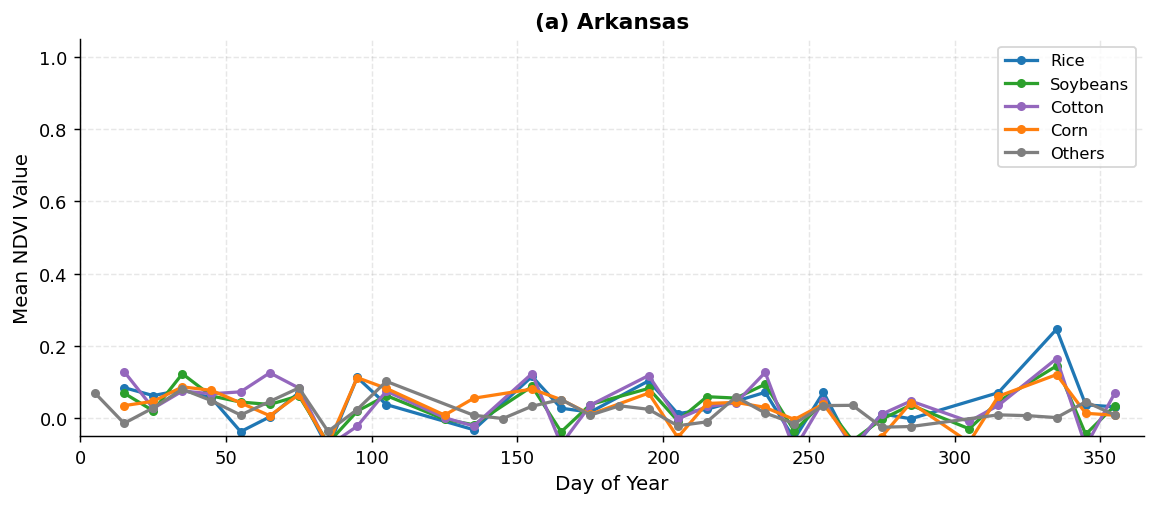

  NDVI California sauvegarde -> data\processed\ndvi_california.png


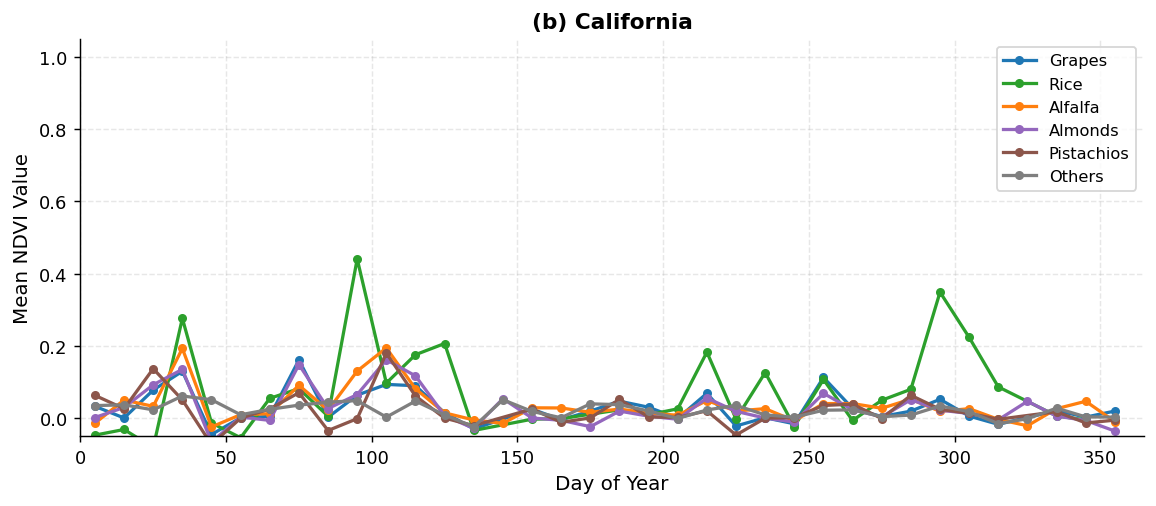

In [ ]:
CA_COLORS = {
    'Grapes':'#1f77b4','Rice':'#2ca02c','Alfalfa':'#ff7f0e',
    'Almonds':'#9467bd','Pistachios':'#8c564b','Others':'#7f7f7f'
}
AR_COLORS = {
    'Soybeans':'#2ca02c','Rice':'#1f77b4','Corn':'#ff7f0e',
    'Cotton':'#9467bd','Others':'#7f7f7f'
}

def plot_ndvi_profiles(csv_path, order, color_map, label, sub='a', label_map=None):
   
    df = pd.read_csv(csv_path)

    # ── Détection automatique du format CSV ──────────────────────────────────
    if 'crop_label' in df.columns:
        # Format SAFE : colonnes déjà dans l'ordre ALL_BANDS × 36 slots
        feat_cols  = [c for c in df.columns if c not in ['crop_label', 'split']]
        raw_labels = df['crop_label'].values
        X = df[feat_cols].values.reshape(-1, 36, N_BANDS).astype(float)
    else:
       
        feat_cols = [c for c in df.columns if c != 'label']
        def sort_key(col):
            band, t = col.rsplit('_t', 1)
            return (BAND_ORDER_WIDE.index(band), int(t))
        feat_cols = sorted(feat_cols, key=sort_key)
        if label_map is not None:
            raw_labels = np.array([label_map.get(int(v), 'Others') for v in df['label'].values])
        else:
            raw_labels = df['label'].astype(str).values
        band_map = {'B02':'B2','B03':'B3','B04':'B4','B05':'B5','B06':'B6',
                    'B07':'B7','B08':'B8','B8A':'B8A','B11':'B11','B12':'B12'}
        wide_to_paper = []
        for pb in ALL_BANDS:
            bi = BAND_ORDER_WIDE.index(band_map[pb])
            for t in range(36):
                wide_to_paper.append(bi * 36 + t)
        X = df[feat_cols].values[:, wide_to_paper].astype(float).reshape(-1, 36, N_BANDS)

  
    NIR = X[:, :, IDX_NIR]  
    RED = X[:, :, IDX_RED]  

    MIN_REFL = 0.01         
    valid_slot = (NIR > MIN_REFL) & (RED > MIN_REFL)  
    NDVI = np.where(valid_slot,
                    (NIR - RED) / (NIR + RED + 1e-8),  
                    np.nan)                             
    NDVI = np.clip(NDVI, -0.1, 1.0)  

    # ── Tracé ────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(9, 4))
    doys = np.array(TARGET_DOYS)  

    for cls in order:
        mask_cls = (raw_labels == cls)
        if mask_cls.sum() == 0:
            continue
        mean_ndvi = np.nanmean(NDVI[mask_cls], axis=0)       
        coverage  = (~np.isnan(NDVI[mask_cls])).mean(axis=0) 
        valid     = coverage >= 0.10  
        ax.plot(doys[valid], mean_ndvi[valid],
                marker='o', markersize=4, linewidth=1.8,
                color=color_map.get(cls, 'gray'), label=cls)

    ax.set_xlabel('Day of Year', fontsize=11)
    ax.set_ylabel('Mean NDVI Value', fontsize=11)
    ax.set_title(f'({sub}) {label}', fontsize=12, fontweight='bold')
    ax.set_xlim(0, 365); ax.set_ylim(-0.05, 1.05)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(50))
    ax.legend(loc='upper right', fontsize=9, framealpha=0.8)
    ax.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    try:
        out_path = PROCESSED_DIR / f'ndvi_{label.lower()}.png'
        plt.savefig(out_path, dpi=150, bbox_inches='tight')
    except Exception:
        out_path = Path(f'ndvi_{label.lower()}.png')
        plt.savefig(out_path, dpi=150, bbox_inches='tight')
    print(f'  NDVI {label} sauvegarde -> {out_path}')
    plt.show()


ndvi_csv_AR = TRAIN_CSV_WIDE_AR if TRAIN_CSV_WIDE_AR.exists() else TRAIN_CSV_AR
ndvi_csv_CA = TRAIN_CSV_WIDE_CA if TRAIN_CSV_WIDE_CA.exists() else TRAIN_CSV_CA

plot_ndvi_profiles(ndvi_csv_AR, AR_ORDER, AR_COLORS, 'Arkansas',   'a', label_map=AR_LABEL_MAP)
plot_ndvi_profiles(ndvi_csv_CA, CA_ORDER, CA_COLORS, 'California', 'b', label_map=CA_LABEL_MAP)

### Matrices de confusion normalisees — Fig. 7 & 8 du paper

=== Arkansas — MCTNet ===
  OA=0.8569  Kappa=0.7929  F1=0.7975

  Matrice sauvegardee -> data\processed\confusion_arkansas_full.png


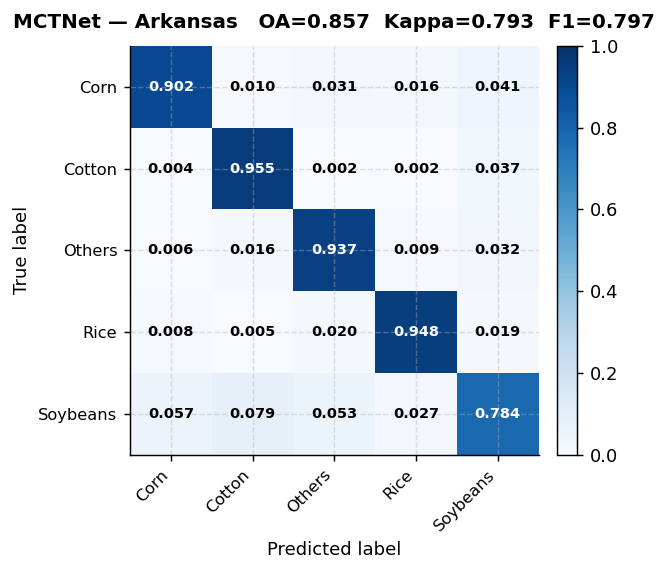

  F1 par classe Arkansas sauvegarde


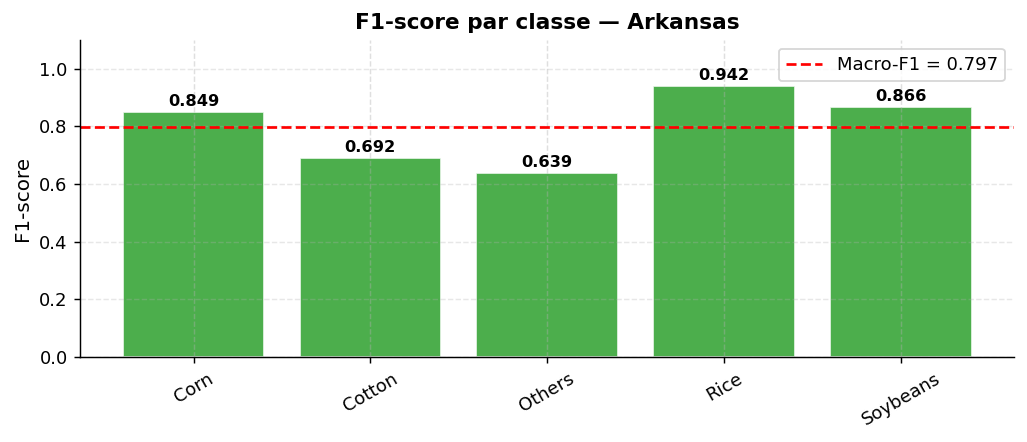


=== California — MCTNet ===
  OA=0.8161  Kappa=0.7605  F1=0.7404

  Matrice sauvegardee -> data\processed\confusion_california_full.png


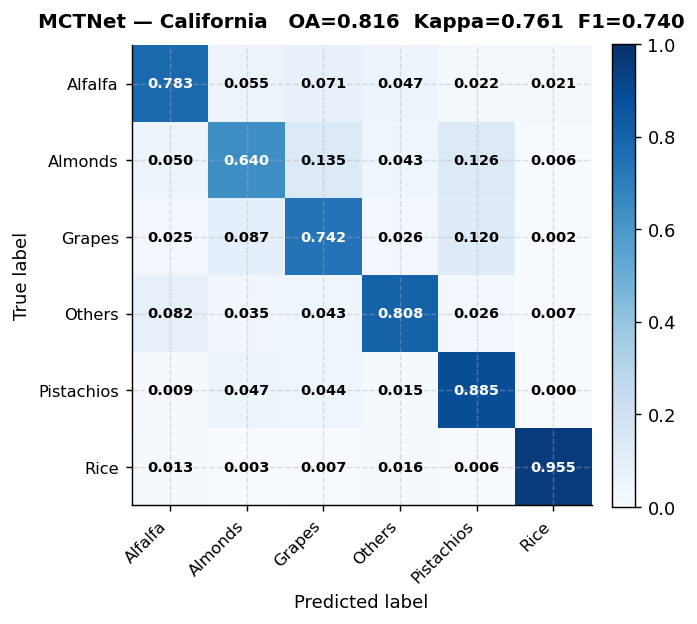

  F1 par classe California sauvegarde


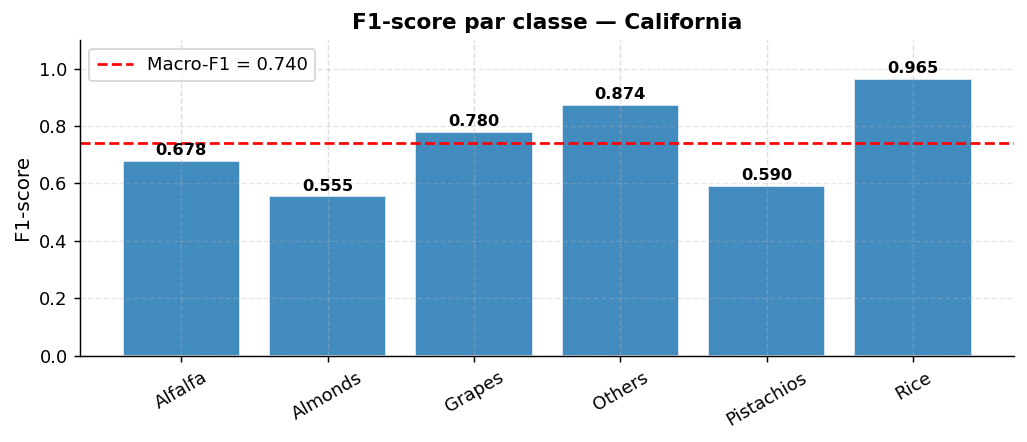

In [70]:
def plot_confusion_matrices_paper(y_true, y_pred, classes, title='', filename=None):
    """
    Matrice de confusion normalisée — style exact des Fig. 7 et 8 du paper
    (Wang et al. 2024, Computers and Electronics in Agriculture).

    Normalisation : par ligne (True label), chaque ligne somme à 1.0.
    Affichage    : valeurs avec 3 décimales, texte blanc si cellule > 0.5.
    Colormap     : Blues (diagonal dominant = bleu foncé = bon résultat).
    """
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_true, y_pred, normalize='true')  # normalisation par ligne
    n  = len(classes)

    fig, ax = plt.subplots(figsize=(max(5, n*0.9), max(4.5, n*0.85)))
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)  # barre de couleur à droite

    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels(classes, fontsize=9, rotation=45, ha='right')
    ax.set_yticklabels(classes, fontsize=9)
    ax.set_xlabel('Predicted label', fontsize=10)
    ax.set_ylabel('True label', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=10)

    # Annoter chaque cellule avec sa valeur
    for i in range(n):
        for j in range(n):
            # Texte blanc sur fond sombre (> 0.5), noir sur fond clair
            color = 'white' if cm[i, j] > 0.5 else 'black'
            ax.text(j, i, f'{cm[i,j]:.3f}', ha='center', va='center',
                    fontsize=8 if n <= 6 else 6, color=color, fontweight='bold')

    plt.tight_layout()
    if filename:
        out = PROCESSED_DIR / filename
        plt.savefig(out, dpi=150, bbox_inches='tight')
        print(f'  Matrice sauvegardee -> {out}')
    plt.show()
    return cm


def plot_per_class_f1(y_true, y_pred, classes, label, color):
    """
    Diagramme en barres des F1-scores par classe.

    Complète la matrice de confusion : identifie rapidement quelles cultures
    sont bien ou mal classifiées.
    F1 = 2 * precision * recall / (precision + recall)  (harmonie P et R)
    La ligne rouge horizontale indique le Macro-F1 global.
    """
    from sklearn.metrics import f1_score
    f1_per_class = f1_score(y_true, y_pred, average=None,
                            labels=list(range(len(classes))))
    fig, ax = plt.subplots(figsize=(8, 3.5))
    bars = ax.bar(classes, f1_per_class, color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, f1_per_class):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    # Ligne Macro-F1 (conforme paper : moyenne non-pondérée des F1 par classe)
    ax.axhline(np.mean(f1_per_class), color='red', linestyle='--', linewidth=1.5,
               label=f'Macro-F1 = {np.mean(f1_per_class):.3f}')
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('F1-score', fontsize=11)
    ax.set_title(f'F1-score par classe — {label}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, axis='y', alpha=0.3, linestyle='--')
    ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.savefig(PROCESSED_DIR / f'f1_per_class_{label.lower()}.png', dpi=150, bbox_inches='tight')
    print(f'  F1 par classe {label} sauvegarde')
    plt.show()


# ── Arkansas ── style Fig. 7 ──────────────────────────────────────────────────
from sklearn.metrics import cohen_kappa_score, f1_score

oa_ar    = (pred_AR == y_test_AR).mean()
kappa_ar = cohen_kappa_score(y_test_AR, pred_AR)
f1_ar    = f1_score(y_test_AR, pred_AR, average='macro')
print(f"=== Arkansas — MCTNet ===\n  OA={oa_ar:.4f}  Kappa={kappa_ar:.4f}  F1={f1_ar:.4f}\n")

plot_confusion_matrices_paper(
    y_test_AR, pred_AR, list(le_AR.classes_),
    title=f'MCTNet — Arkansas   OA={oa_ar:.3f}  Kappa={kappa_ar:.3f}  F1={f1_ar:.3f}',
    filename='confusion_arkansas_full.png')
plot_per_class_f1(y_test_AR, pred_AR, list(le_AR.classes_), 'Arkansas', '#2ca02c')

# ── California ── style Fig. 8 ────────────────────────────────────────────────
oa_ca    = (pred_CA == y_test_CA).mean()
kappa_ca = cohen_kappa_score(y_test_CA, pred_CA)
f1_ca    = f1_score(y_test_CA, pred_CA, average='macro')
print(f"\n=== California — MCTNet ===\n  OA={oa_ca:.4f}  Kappa={kappa_ca:.4f}  F1={f1_ca:.4f}\n")

plot_confusion_matrices_paper(
    y_test_CA, pred_CA, list(le_CA.classes_),
    title=f'MCTNet — California   OA={oa_ca:.3f}  Kappa={kappa_ca:.3f}  F1={f1_ca:.3f}',
    filename='confusion_california_full.png')
plot_per_class_f1(y_test_CA, pred_CA, list(le_CA.classes_), 'California', '#1f77b4')

## 📊 Profils spectraux par culture (Visualisation complémentaire)
Réflectance de chaque bande Sentinel-2 au moment du pic NDVI par culture.

  Profils spectraux Arkansas sauvegardes


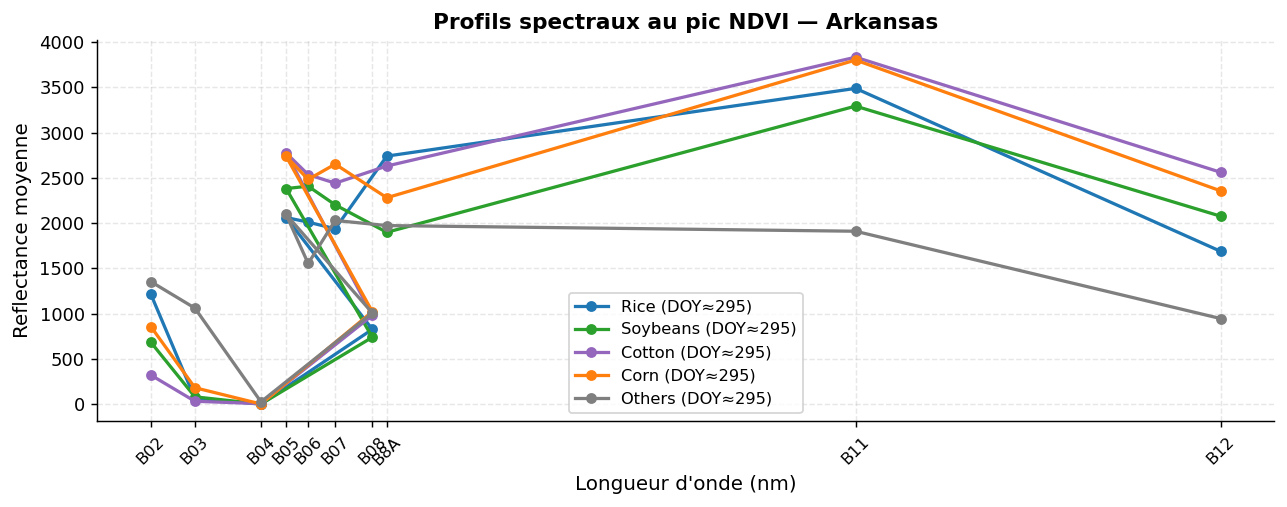

  Profils spectraux California sauvegardes


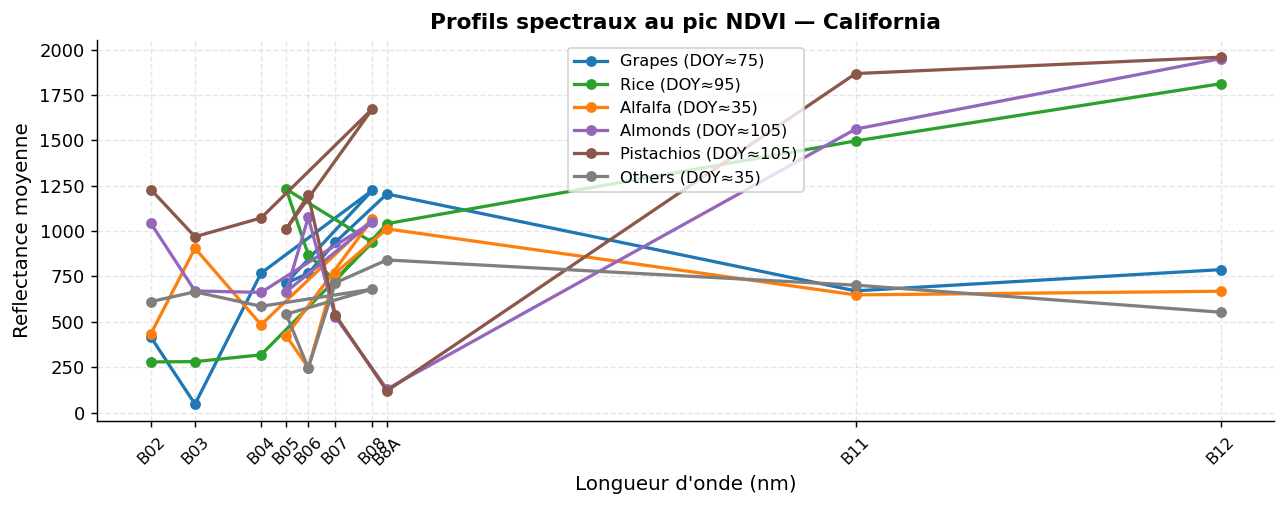

In [71]:
def plot_spectral_profiles(csv_path, order, color_map, label, label_map=None):
    """
    Visualise les profils spectraux moyens par culture au moment du pic NDVI.

    Objectif : montrer la séparabilité spectrale entre cultures.
    Chaque courbe représente la réflectance moyenne de la culture sur les 10
    bandes Sentinel-2, à la date où son NDVI est maximal.

    Les longueurs d'onde (nm) correspondent aux bandes Sentinel-2 :
    B02=490, B03=560, B04=665, B05=705, B06=740, B07=783,
    B08=842, B8A=865, B11=1610, B12=2190
    """
    df = pd.read_csv(csv_path)
    if 'crop_label' in df.columns:
        feat_cols  = [c for c in df.columns if c not in ['crop_label', 'split']]
        raw_labels = df['crop_label'].values
        X = df[feat_cols].values.reshape(-1, 36, N_BANDS).astype(float)
    else:
        feat_cols = [c for c in df.columns if c != 'label']
        def sort_key(col):
            band, t = col.rsplit('_t', 1)
            return (BAND_ORDER_WIDE.index(band), int(t))
        feat_cols = sorted(feat_cols, key=sort_key)
        if label_map is not None:
            raw_labels = np.array([label_map.get(int(v), 'Others') for v in df['label'].values])
        else:
            raw_labels = df['label'].astype(str).values
        band_map = {'B02':'B2','B03':'B3','B04':'B4','B05':'B5','B06':'B6',
                    'B07':'B7','B08':'B8','B8A':'B8A','B11':'B11','B12':'B12'}
        wide_to_paper = []
        for pb in ALL_BANDS:
            bi = BAND_ORDER_WIDE.index(band_map[pb])
            for t in range(36):
                wide_to_paper.append(bi * 36 + t)
        X = df[feat_cols].values[:, wide_to_paper].astype(float).reshape(-1, 36, N_BANDS)

    # Longueurs d'onde centrales des 10 bandes Sentinel-2 sélectionnées
    band_wavelengths = {
        'B02':490,'B03':560,'B04':665,'B05':705,'B06':740,
        'B07':783,'B08':842,'B8A':865,'B11':1610,'B12':2190
    }
    wavelengths = [band_wavelengths[b] for b in ALL_BANDS]

    fig, ax = plt.subplots(figsize=(10, 4))
    for cls in order:
        mask_cls = (raw_labels == cls)
        if mask_cls.sum() == 0: continue
        X_cls = X[mask_cls]
        # Trouver le slot de pic NDVI pour cette classe
        NIR = X_cls[:, :, IDX_NIR]; RED = X_cls[:, :, IDX_RED]
        valid = (NIR > 0.01) & (RED > 0.01)
        ndvi  = np.where(valid, (NIR-RED)/(NIR+RED+1e-8), np.nan)
        mean_ndvi_ts = np.nanmean(ndvi, axis=0)  # NDVI moyen par slot
        peak_slot = int(np.nanargmax(mean_ndvi_ts))  # slot au pic NDVI
        # Profil spectral au slot de pic
        profile  = X_cls[:, peak_slot, :]
        valid_px = (profile.sum(axis=1) > 0)  # pixels non-nuls
        mean_spec = profile[valid_px].mean(axis=0)
        ax.plot(wavelengths, mean_spec, marker='o', linewidth=1.8, markersize=5,
                color=color_map.get(cls, 'gray'),
                label=f'{cls} (DOY≈{TARGET_DOYS[peak_slot]})')

    ax.set_xlabel("Longueur d'onde (nm)", fontsize=11)
    ax.set_ylabel('Reflectance moyenne', fontsize=11)
    ax.set_title(f'Profils spectraux au pic NDVI — {label}', fontsize=12, fontweight='bold')
    ax.set_xticks(wavelengths)
    ax.set_xticklabels(ALL_BANDS, rotation=45, fontsize=9)
    ax.legend(fontsize=9, framealpha=0.8)
    ax.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.savefig(PROCESSED_DIR / f'spectral_{label.lower()}.png', dpi=150, bbox_inches='tight')
    print(f'  Profils spectraux {label} sauvegardes')
    plt.show()

csv_AR = TRAIN_CSV_WIDE_AR if TRAIN_CSV_WIDE_AR.exists() else TRAIN_CSV_AR
csv_CA = TRAIN_CSV_WIDE_CA if TRAIN_CSV_WIDE_CA.exists() else TRAIN_CSV_CA
plot_spectral_profiles(csv_AR, AR_ORDER, AR_COLORS, 'Arkansas',   label_map=AR_LABEL_MAP)
plot_spectral_profiles(csv_CA, CA_ORDER, CA_COLORS, 'California', label_map=CA_LABEL_MAP)

## 📊 Distribution des classes (Pie + Bar)
Visualise le déséquilibre éventuel entre cultures — impacte le Macro-F1.

  Distribution Arkansas sauvegardee


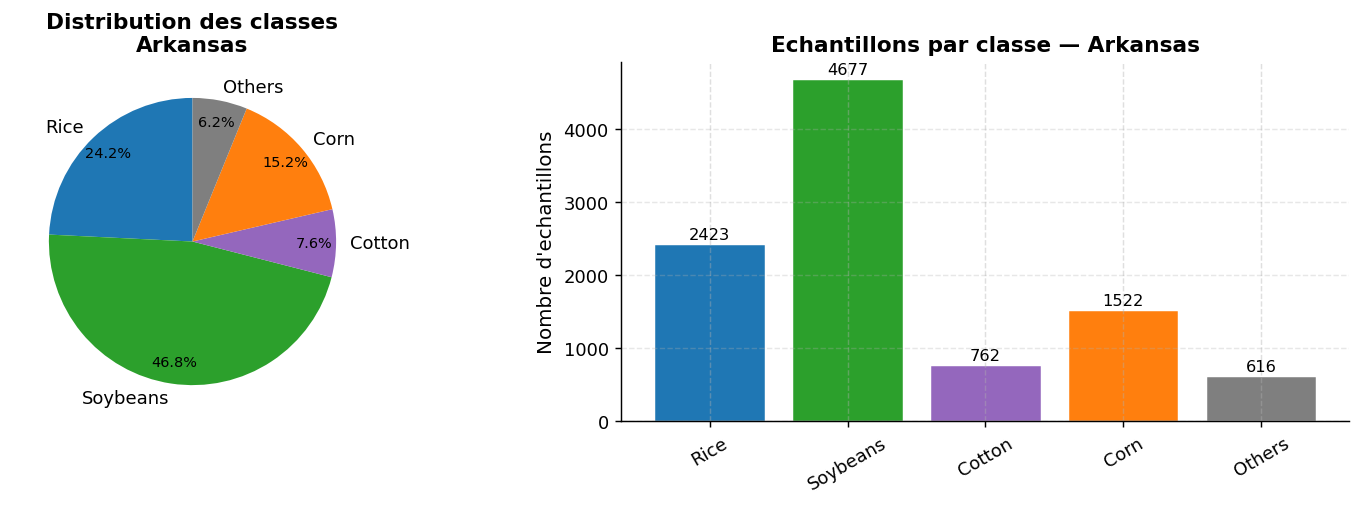

  [Arkansas] Repartition : {'Rice': np.int64(2423), 'Soybeans': np.int64(4677), 'Cotton': np.int64(762), 'Corn': np.int64(1522), 'Others': np.int64(616)}
  Distribution California sauvegardee


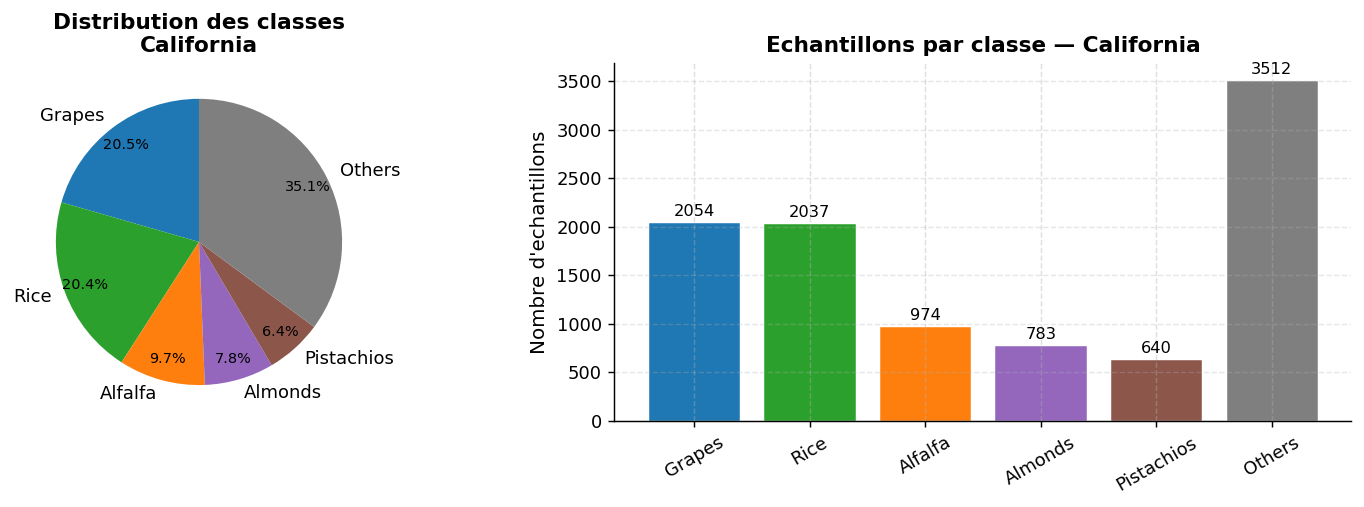

  [California] Repartition : {'Grapes': np.int64(2054), 'Rice': np.int64(2037), 'Alfalfa': np.int64(974), 'Almonds': np.int64(783), 'Pistachios': np.int64(640), 'Others': np.int64(3512)}


In [72]:
def plot_class_distribution(csv_path, order, color_map, label, label_map=None):
    """
    Visualise la distribution des classes (pie chart + bar chart).

    Pourquoi c'est important :
    - Un dataset déséquilibré pénalise les petites classes en classification.
    - Le macro-F1 (Table 5 du paper) pondère chaque classe équitablement,
      ce qui compense ce déséquilibre par rapport à l'OA pure.
    - Visualiser la distribution aide à interpréter les erreurs de classification.
    """
    df = pd.read_csv(csv_path)
    if 'crop_label' in df.columns:
        raw_labels = df['crop_label'].values
    else:
        if label_map is not None:
            raw_labels = np.array([label_map.get(int(v), 'Others') for v in df['label'].values])
        else:
            raw_labels = df['label'].astype(str).values

    # Compter les occurrences par classe
    counts = {cls: (raw_labels == cls).sum() for cls in order}
    labels_list = list(counts.keys())
    values_list = list(counts.values())
    colors_list = [color_map.get(c, '#999') for c in labels_list]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # ── Pie chart : proportions relatives ────────────────────────────────────
    wedges, texts, autotexts = ax1.pie(
        values_list, labels=labels_list, colors=colors_list,
        autopct='%1.1f%%', startangle=90, pctdistance=0.85
    )
    for t in autotexts: t.set_fontsize(8)
    ax1.set_title(f'Distribution des classes\n{label}', fontweight='bold')

    # ── Bar chart : compte absolu ─────────────────────────────────────────────
    bars = ax2.bar(labels_list, values_list, color=colors_list,
                   edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, values_list):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 str(val), ha='center', va='bottom', fontsize=9)
    ax2.set_ylabel("Nombre d'echantillons", fontsize=11)
    ax2.set_title(f'Echantillons par classe — {label}', fontweight='bold')
    ax2.tick_params(axis='x', rotation=30)
    ax2.grid(True, axis='y', alpha=0.3, linestyle='--')

    plt.tight_layout()
    plt.savefig(PROCESSED_DIR / f'class_dist_{label.lower()}.png', dpi=150, bbox_inches='tight')
    print(f'  Distribution {label} sauvegardee')
    plt.show()
    print(f'  [{label}] Repartition : {counts}')

csv_AR = TRAIN_CSV_WIDE_AR if TRAIN_CSV_WIDE_AR.exists() else TRAIN_CSV_AR
csv_CA = TRAIN_CSV_WIDE_CA if TRAIN_CSV_WIDE_CA.exists() else TRAIN_CSV_CA
plot_class_distribution(csv_AR, AR_ORDER, AR_COLORS, 'Arkansas',   label_map=AR_LABEL_MAP)
plot_class_distribution(csv_CA, CA_ORDER, CA_COLORS, 'California', label_map=CA_LABEL_MAP)

## 🗺️ Visualisation Crop Map — style Fig. 9 & 10 du paper
Simulation d'une carte de cultures (True Map / Predicted Map / Residual Map).
 """
    Simule une carte de cultures dans l'esprit des Fig. 9 et 10 du paper.

    Comme nous travaillons avec des pixels ponctuels (sans coordonnees geo),
    les pixels sont arranges dans une grille carree de n_side × n_side.
    Trois cartes sont affichees cote a cote :
      - True Map      : vraies classes (couleurs CDL)
      - Predicted Map : classes predites par MCTNet
      - Residual Map  : blanc = correct, noir = erreur (style exact du paper)

    Cette visualisation permet d'evaluer visuellement la distribution spatiale
    des erreurs et correspond a la Figs. 9-10 de Wang et al. 2024.
    """

=== Crop Map Style Fig. 9 — Arkansas ===
  Crop map Arkansas sauvegardee (accuracy globale = 0.857)


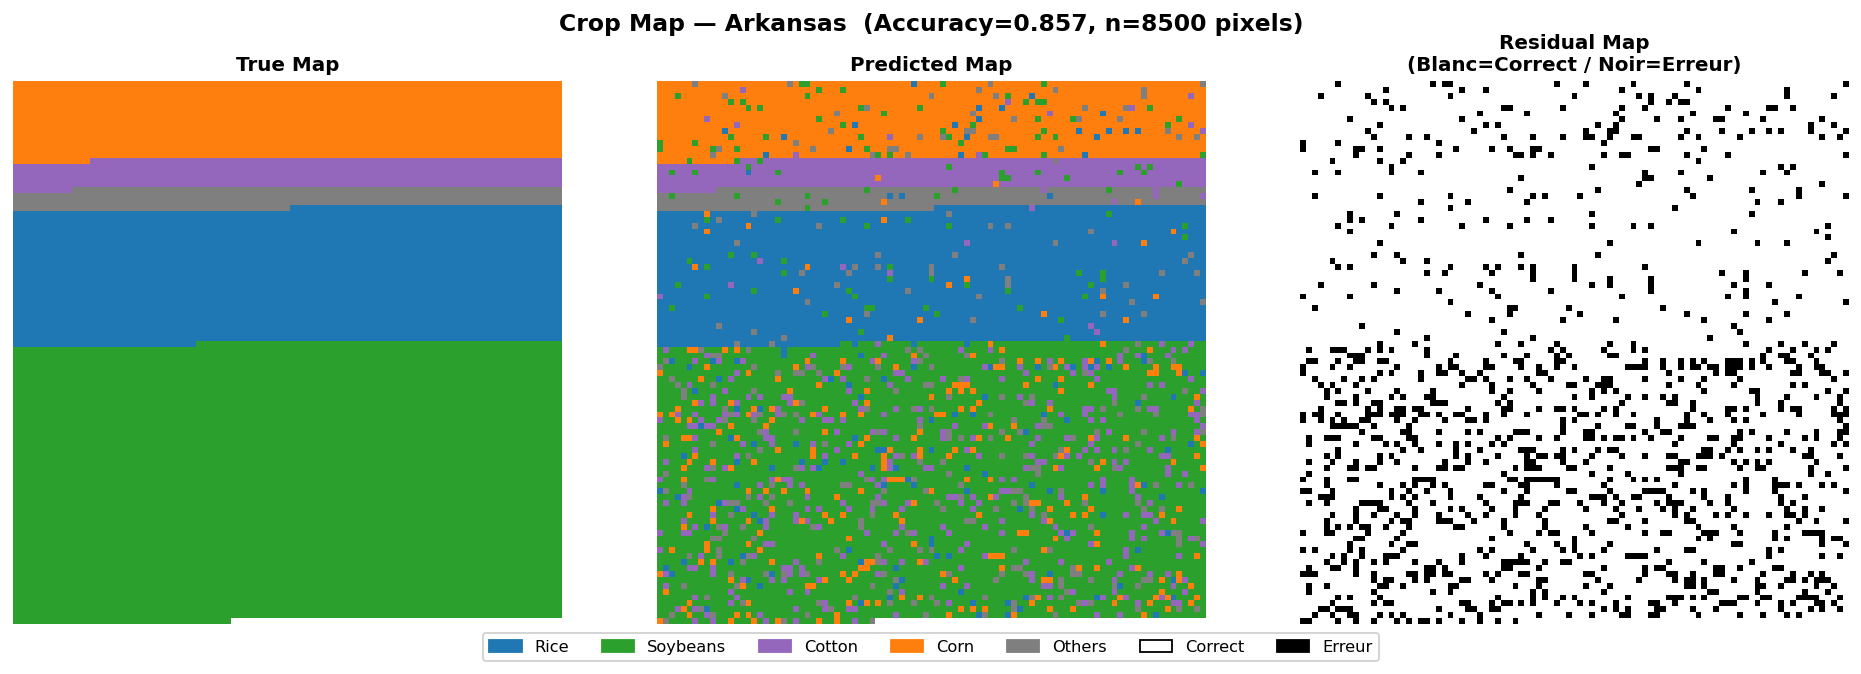


  ── Mapping accuracy par classe (Arkansas) ── style Table 7
    Corn           : 0.902  (n=1222)
    Cotton         : 0.955  (n=462)
    Others         : 0.937  (n=316)
    Rice           : 0.948  (n=2123)
    Soybeans       : 0.784  (n=4377)

=== Crop Map Style Fig. 10 — California ===
  Crop map California sauvegardee (accuracy globale = 0.816)


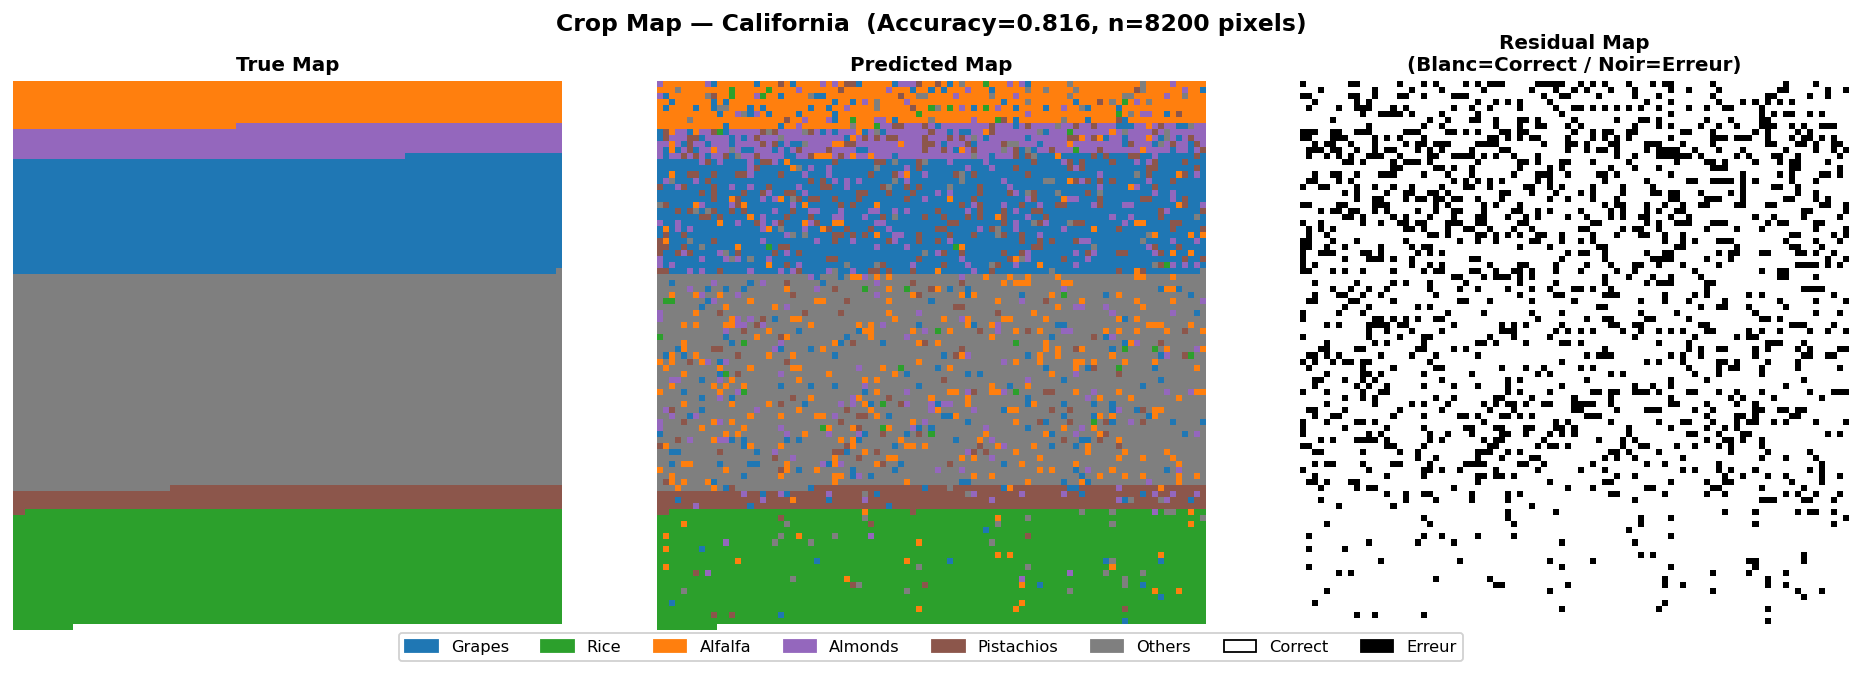


  ── Mapping accuracy par classe (California) ── style Table 7
    Alfalfa        : 0.783  (n=674)
    Almonds        : 0.640  (n=483)
    Grapes         : 0.742  (n=1754)
    Others         : 0.808  (n=3212)
    Pistachios     : 0.885  (n=340)
    Rice           : 0.955  (n=1737)


In [ ]:
def simulate_crop_map(y_true, y_pred, le, color_map, order, label, n_side=100):
   
    import matplotlib.patches as mpatches

    classes = list(le.classes_)
    n_pix   = min(n_side * n_side, len(y_true))
    yt = y_true[:n_pix]; yp = y_pred[:n_pix]

    def labels_to_rgb(labels_enc, le_classes, cmap_dict):
        """Convertit encodages → image RGB en grille carree."""
        h = w = int(np.ceil(np.sqrt(len(labels_enc))))
        img = np.ones((h * w, 3), dtype=np.float32)
        for i, enc in enumerate(labels_enc):
            cls_name  = le_classes[enc]
            hex_color = cmap_dict.get(cls_name, '#cccccc')
            r = int(hex_color[1:3],16)/255
            g = int(hex_color[3:5],16)/255
            b = int(hex_color[5:7],16)/255
            img[i] = [r, g, b]
        return img.reshape(h, w, 3)

    img_true = labels_to_rgb(yt, classes, color_map)
    img_pred = labels_to_rgb(yp, classes, color_map)

    # Residual map : blanc = correct, noir = erreur (style paper)
    h = w = int(np.ceil(np.sqrt(n_pix)))
    residual = np.ones((h * w, 3), dtype=np.float32)
    for i in range(n_pix):
        residual[i] = [1,1,1] if yt[i] == yp[i] else [0,0,0]
    residual = residual.reshape(h, w, 3)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img_true);    axes[0].set_title('True Map',      fontsize=11, fontweight='bold')
    axes[1].imshow(img_pred);    axes[1].set_title('Predicted Map', fontsize=11, fontweight='bold')
    axes[2].imshow(residual);    axes[2].set_title('Residual Map\n(Blanc=Correct / Noir=Erreur)',
                                                     fontsize=11, fontweight='bold')
    for ax in axes: ax.axis('off')

    # Legende partagee (couleurs des cultures + correct/erreur)
    patches = [mpatches.Patch(color=color_map.get(c,'#ccc'), label=c)
               for c in order if c in classes]
    patches += [mpatches.Patch(color='white', label='Correct', ec='black'),
                mpatches.Patch(color='black', label='Erreur')]
    fig.legend(handles=patches, loc='lower center', ncol=len(order)+2,
               bbox_to_anchor=(0.5, -0.03), fontsize=9, framealpha=0.9)

    pct_correct = (yt == yp).mean()
    plt.suptitle(f'Crop Map — {label}  (Accuracy={pct_correct:.3f}, n={n_pix} pixels)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(PROCESSED_DIR / f'cropmap_{label.lower()}.png', dpi=150, bbox_inches='tight')
    print(f'  Crop map {label} sauvegardee (accuracy globale = {pct_correct:.3f})')
    plt.show()

    # Accuracy par classe — style Table 7 du paper
    print(f"\n  ── Mapping accuracy par classe ({label}) ── style Table 7")
    for cls_idx, cls in enumerate(classes):
        mask = (yt == cls_idx)
        if mask.sum() == 0: continue
        acc_cls = (yp[mask] == yt[mask]).mean()
        print(f"    {cls:<15s}: {acc_cls:.3f}  (n={mask.sum()})")


print("=== Crop Map Style Fig. 9 — Arkansas ===")
simulate_crop_map(y_test_AR, pred_AR, le_AR, AR_COLORS, AR_ORDER, 'Arkansas')

print("\n=== Crop Map Style Fig. 10 — California ===")
simulate_crop_map(y_test_CA, pred_CA, le_CA, CA_COLORS, CA_ORDER, 'California')

## 📋 Tableau Comparatif — Notre MCTNet vs Paper (Table 5)
Comparaison directe OA / Kappa / Macro-F1 entre notre implémentation et les résultats publiés.
    """
    Tableau comparatif complet entre notre implementation MCTNet et le paper.

    Compare sur les deux zones (Arkansas et California) les trois metriques :
      - OA    : Overall Accuracy = pourcentage de pixels correctement classes
      - Kappa : Coefficient Kappa de Cohen (agreement au-dela du hasard)
      - F1    : Macro-averaged F1 = moyenne des F1 par classe (Table 5 paper)

    Les resultats du paper proviennent de Wang et al. 2024 (Table 5).
    Les deltas (Delta) indiquent si notre implementation est au-dessus (+) ou
    en dessous (-) des resultats publies.
    """


  COMPARATIF MCTNet : Notre Implementation vs Paper (Table 5)

── Arkansas ──
        Modele    OA  Kappa    F1                                Source
        MCTNet 0.968  0.951 0.933                                 Paper
        GL-TAE 0.952  0.928 0.905                                 Paper
          LTAE 0.941  0.912 0.884                                 Paper
        ResNet 0.945  0.917 0.894                                 Paper
   Transformer 0.956  0.934 0.909                                 Paper
          LSTM 0.907  0.862 0.843                                 Paper
            RF 0.936  0.904 0.887                                 Paper
           SVM 0.910  0.867 0.846                                 Paper
MCTNet (Notre) 0.857  0.793 0.797 Nous  dOA=-0.111 dK=-0.158 dF1=-0.136

── California ──
        Modele    OA  Kappa    F1                                Source
        MCTNet 0.852  0.806 0.829                                 Paper
        GL-TAE 0.843  0.796 0.820      

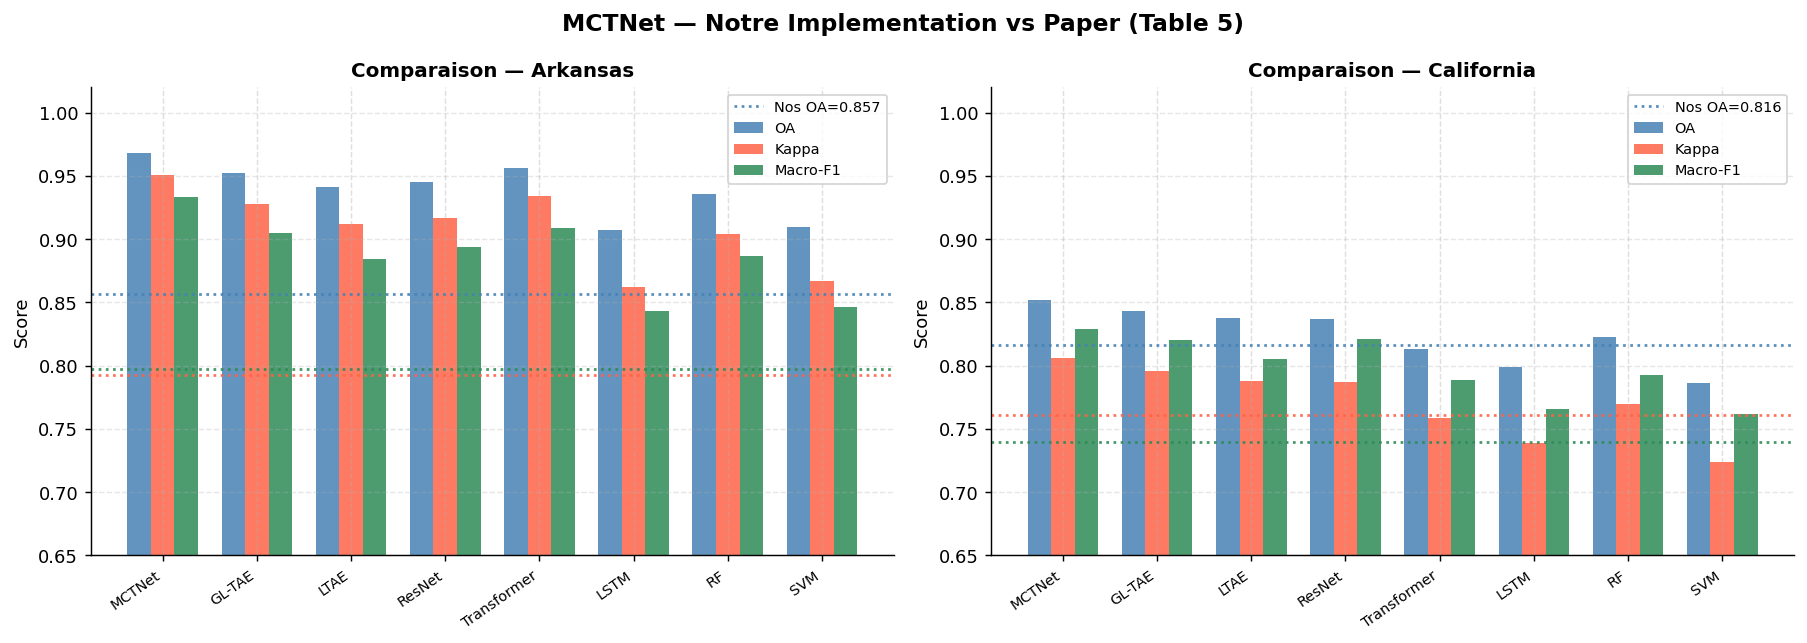

In [ ]:
def print_comparative_table():

    from sklearn.metrics import cohen_kappa_score, f1_score

    # ── Resultats publiés — Table 5 du paper ──────────────────────────────────
    paper = {
        'Arkansas': {
            'MCTNet':      (0.968, 0.951, 0.933),
            'GL-TAE':      (0.952, 0.928, 0.905),
            'LTAE':        (0.941, 0.912, 0.884),
            'ResNet':      (0.945, 0.917, 0.894),
            'Transformer': (0.956, 0.934, 0.909),
            'LSTM':        (0.907, 0.862, 0.843),
            'RF':          (0.936, 0.904, 0.887),
            'SVM':         (0.910, 0.867, 0.846),
        },
        'California': {
            'MCTNet':      (0.852, 0.806, 0.829),
            'GL-TAE':      (0.843, 0.796, 0.820),
            'LTAE':        (0.838, 0.788, 0.805),
            'ResNet':      (0.837, 0.787, 0.821),
            'Transformer': (0.813, 0.759, 0.789),
            'LSTM':        (0.799, 0.739, 0.766),
            'RF':          (0.823, 0.770, 0.793),
            'SVM':         (0.786, 0.724, 0.762),
        }
    }

    # ── Nos resultats (calcules sur le jeu de test) ───────────────────────────
    our = {
        'Arkansas':   (round((pred_AR==y_test_AR).mean(),3),
                       round(cohen_kappa_score(y_test_AR, pred_AR),3),
                       round(f1_score(y_test_AR, pred_AR, average='macro'),3)),
        'California': (round((pred_CA==y_test_CA).mean(),3),
                       round(cohen_kappa_score(y_test_CA, pred_CA),3),
                       round(f1_score(y_test_CA, pred_CA, average='macro'),3)),
    }

    # ── Construction du DataFrame ──────────────────────────────────────────────
    rows = []
    for region in ['Arkansas', 'California']:
        for model, (oa, kappa, f1) in paper[region].items():
            rows.append({'Region':region,'Modele':model,'OA':oa,'Kappa':kappa,'F1':f1,'Source':'Paper'})
        n_oa, n_k, n_f1 = our[region]
        p_oa, p_k, p_f1 = paper[region]['MCTNet']
        rows.append({'Region':region,'Modele':'MCTNet (Notre)',
                     'OA':n_oa,'Kappa':n_k,'F1':n_f1,
                     'Source':f'Nous  dOA={n_oa-p_oa:+.3f} dK={n_k-p_k:+.3f} dF1={n_f1-p_f1:+.3f}'})

    df_comp = pd.DataFrame(rows)
    print("\n" + "="*75)
    print("  COMPARATIF MCTNet : Notre Implementation vs Paper (Table 5)")
    print("="*75)
    for region in ['Arkansas', 'California']:
        sub = df_comp[df_comp['Region']==region].drop(columns=['Region'])
        print(f"\n── {region} ──")
        print(sub.to_string(index=False))
    print("="*75)

    # ── Visualisation graphique ────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax_idx, region in enumerate(['Arkansas', 'California']):
        ax = axes[ax_idx]
        # Modeles paper seulement (sans notre doublon)
        models_p = [m for m in paper[region].keys()]
        oa_v  = [paper[region][m][0] for m in models_p]
        k_v   = [paper[region][m][1] for m in models_p]
        f1_v  = [paper[region][m][2] for m in models_p]

        x = np.arange(len(models_p)); w = 0.25
        ax.bar(x-w, oa_v, w, label='OA',       color='steelblue', alpha=0.85)
        ax.bar(x,   k_v,  w, label='Kappa',    color='tomato',    alpha=0.85)
        ax.bar(x+w, f1_v, w, label='Macro-F1', color='seagreen',  alpha=0.85)

        # Lignes horizontales = nos resultats
        our_oa, our_k, our_f1 = our[region]
        ax.axhline(our_oa, color='steelblue', linestyle=':', lw=1.5, alpha=0.9, label=f'Nos OA={our_oa:.3f}')
        ax.axhline(our_k,  color='tomato',    linestyle=':', lw=1.5, alpha=0.9)
        ax.axhline(our_f1, color='seagreen',  linestyle=':', lw=1.5, alpha=0.9)

        ax.set_xticks(x)
        ax.set_xticklabels(models_p, rotation=35, ha='right', fontsize=8)
        ax.set_ylim(0.65, 1.02)
        ax.set_ylabel('Score', fontsize=10)
        ax.set_title(f'Comparaison — {region}', fontsize=11, fontweight='bold')
        ax.legend(fontsize=8)
        ax.grid(True, axis='y', alpha=0.3, linestyle='--')

    plt.suptitle('MCTNet — Notre Implementation vs Paper (Table 5)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(PROCESSED_DIR / 'comparative_table_chart.png', dpi=150, bbox_inches='tight')
    print('  Graphique comparatif sauvegarde')
    plt.show()

print_comparative_table()

### 💾 Sauvegarde du modèle

In [76]:
def save_model(model, path, num_classes, le, scaler, history, test_acc, n_dates, label):
    torch.save({
        'model_state_dict': model.state_dict(),
        'num_classes'     : num_classes,
        'label_classes'   : list(le.classes_),
        'scaler'          : scaler,
        'history'         : history,
        'test_accuracy'   : test_acc,
        'n_dates'         : n_dates,
        'n_bands'         : N_BANDS,
    }, path)
    print(f'✅ [{label}] Modèle sauvegardé : {path}')
    print(f'   Accuracy test : {test_acc:.2f}%')

save_model(model_CA, MODEL_PATH_CA, num_classes_CA, le_CA, scaler_CA, history_CA, test_acc_CA, len(DATES_MAP_CA), 'CALIFORNIA')
save_model(model_AR, MODEL_PATH_AR, num_classes_AR, le_AR, scaler_AR, history_AR, test_acc_AR, len(DATES_MAP_AR), 'ARKANSAS')

print('\n🎉 Pipeline MCT-Net complet — California + Arkansas terminé !')


✅ [CALIFORNIA] Modèle sauvegardé : models\mctnet_california_final.pth
   Accuracy test : 81.61%
✅ [ARKANSAS] Modèle sauvegardé : models\mctnet_arkansas_final.pth
   Accuracy test : 85.69%

🎉 Pipeline MCT-Net complet — California + Arkansas terminé !
